### Compare SESN models with Khakpash+24 results

In [1]:
from caat import SNModel
from caat.utils import ROOT_DIR, WLE
import os
import pickle as pkl
import matplotlib.pyplot as plt

In [2]:
# Load Khakpash+24 model grid
with open(os.path.join(ROOT_DIR, "data", "comparison_models", "Khakpash24", "all_templates.pkl"), 'rb') as f:
    u = pkl._Unpickler(f)
    u.encoding = 'latin1'
    tmpl = u.load()

# Generate multi-D GP model
snmodel = SNModel(
    surface="SESNe_SNIIb_GP_model.fits"
)

bands_to_plot = ["w1", "U", "B", "V", "g", "rp", "ip"]
sntype = "IIb"

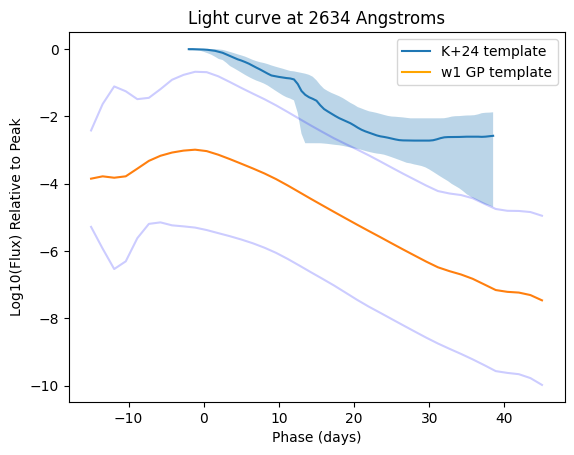

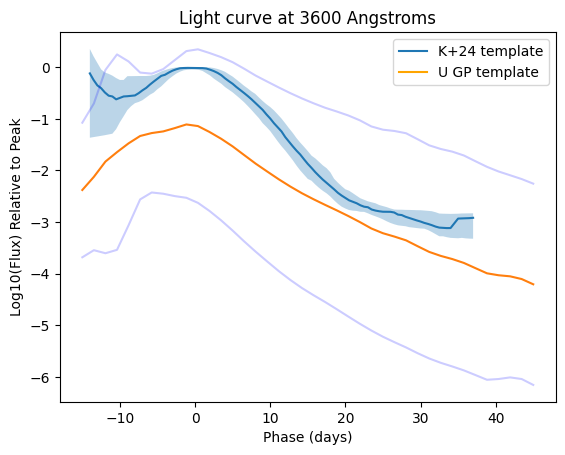

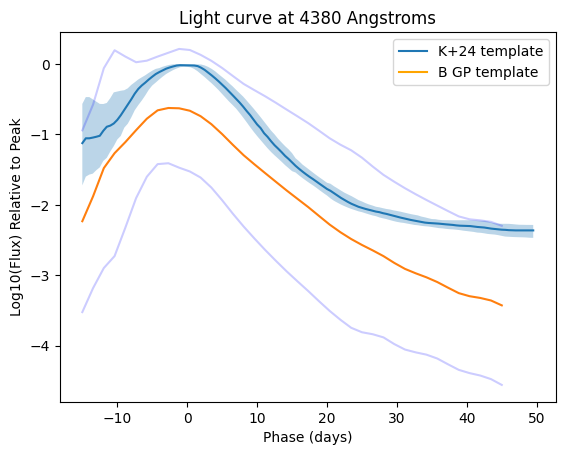

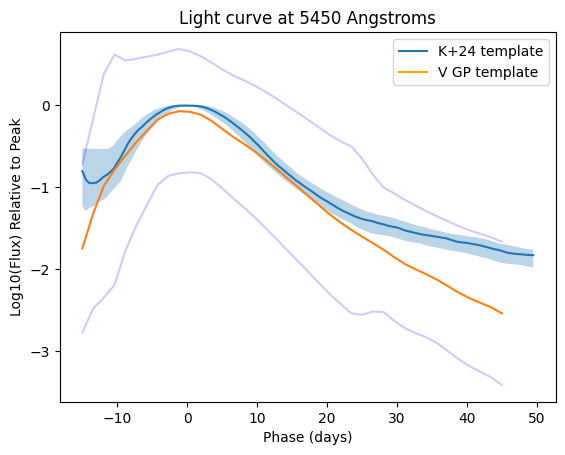

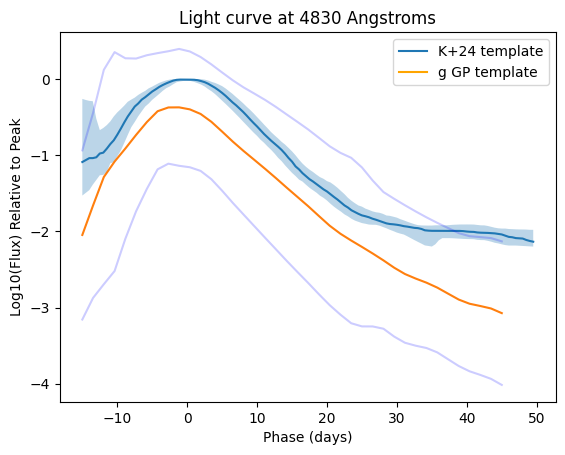

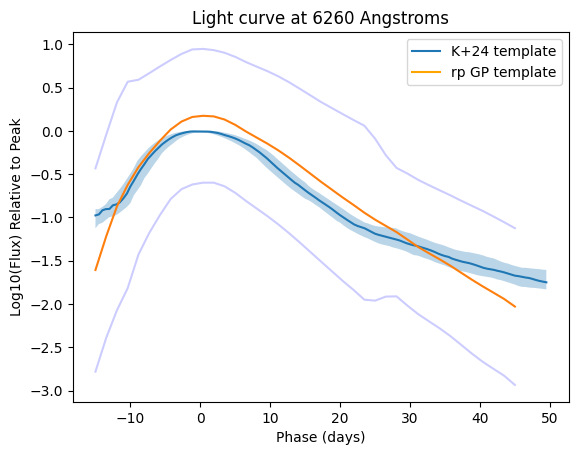

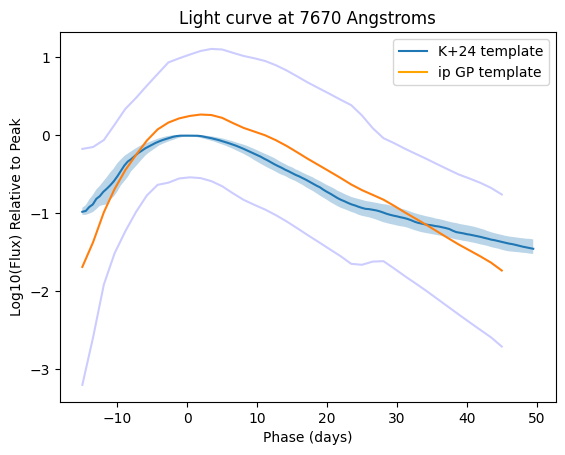

In [3]:
for band in bands_to_plot:
    _, ax = plt.subplots()
    ax.plot(tmpl[band][sntype]['t'], tmpl[band][sntype]['rollingMedian'], label="K+24 template")
    ax.fill_between(
        tmpl[band][sntype]['t'],
        tmpl[band][sntype]['rollingPc25'],
        tmpl[band][sntype]['rollingPc75'],
        alpha=0.3,
    )

    if band in ["w2", "m2", "w1"]:
        caat_band = "UV" + band.upper()
    else:
        caat_band = band[0]
    snmodel.predict_lightcurve(-15.0, 45.0, WLE[caat_band], show=False)
    plt.plot([], [], color='orange', label=f"{band} GP template")
    plt.legend()
    plt.show()

In [4]:
import os
import numpy as np
import pandas as pd
from caat import SN
from caat.utils import ROOT_DIR

CUBE_ROOT = os.path.join(ROOT_DIR, "data/SESNe/")

# Filters present in the GOPREAUX model and their K24 band equivalents
BAND_MAP = {
    # GOPREAUX filter : K24 band name
    "UVW2": "w2",
    "UVM2": "m2",
    "UVW1": "w1",
    "U": "U",
    "B": "B",
    "V": "V",
    "g": "g",
    "r": "rp",
    "i": "ip",
}

MIN_PHASE = -15
MAX_PHASE = 45


def _nightly_bin(df: pd.DataFrame) -> pd.DataFrame:
    """
    Bin intra-night repeat exposures down to one row per filter per night,
    using an inverse-variance weighted mean for magnitude and combined error.
    Rows with Magerr == 0 are excluded from weighting (treated as missing error).
    """
    df = df.copy()
    df["night"] = df["MJD"].astype(int)

    rows = []
    for (filt, night), grp in df.groupby(["ShiftedFilter", "night"]):
        if len(grp) == 1:
            rows.append(grp.iloc[0].to_dict())
            continue

        good = grp[grp["Magerr"] > 0]
        if len(good) == 0:
            # No usable errors — fall back to simple mean
            row = grp.iloc[0].to_dict()
            row["ShiftedMag"] = grp["ShiftedMag"].mean()
            row["MJD"] = grp["MJD"].mean()
            row["Phase"] = grp["Phase"].mean()
        else:
            w = 1.0 / good["Magerr"].values ** 2
            row = good.iloc[0].to_dict()
            row["ShiftedMag"] = float(np.average(good["ShiftedMag"].values, weights=w))
            row["Magerr"] = float(1.0 / np.sqrt(w.sum()))
            row["MJD"] = float(np.average(good["MJD"].values, weights=w))
            row["Phase"] = float(np.average(good["Phase"].values, weights=w))
        rows.append(row)

    return pd.DataFrame(rows).drop(columns=["night"]).reset_index(drop=True)


def load_datacube(
    sn_name: str,
    sn_subtype: str,
    min_phase: float = MIN_PHASE,
    max_phase: float = MAX_PHASE,
) -> pd.DataFrame:
    """Load the mangled datacube for a single SN, keeping only real detections
    within [min_phase, max_phase], and binning any intra-night repeat exposures
    down to one point per night."""
    path = os.path.join(CUBE_ROOT, sn_subtype, sn_name, f"{sn_name}_datacube_mangled.csv")
    cube = pd.read_csv(path, index_col=0)
    # Cast explicitly: pd.read_csv reads booleans as strings or ints from CSV
    cube = cube[~cube["Nondetection"].astype(bool)].reset_index(drop=True)
    cube = cube[(cube["Phase"] >= min_phase) & (cube["Phase"] <= max_phase)].reset_index(drop=True)
    cube = _nightly_bin(cube)
    cube["MagFromPeak"] = SN(name=sn_name).info["peak_mag"] - cube["Mag"]
    return cube


def observed_points(cube: pd.DataFrame, band_map: dict) -> pd.DataFrame:
    """
    Return a tidy DataFrame of observed detections for filters in band_map.

    ShiftedMag = peak_mag - Mag  (magnitude units, 0 at peak, negative for fading).
    """
    rows = []
    for gopreaux_filt, k24_filt in band_map.items():
        subset = cube[cube["ShiftedFilter"] == gopreaux_filt]
        for _, row in subset.iterrows():
            rows.append({
                "Filter": gopreaux_filt,
                "Phase": row["Phase"],
                "Wavelength": row["ShiftedWavelength"],
                "ShiftedMag": row["MagFromPeak"],
                "Magerr": row["Magerr"],
            })
    return pd.DataFrame(rows)


In [5]:
import matplotlib.pyplot as plt
from caat.utils import colors as FILTER_COLORS
from caat.utils import WLE
from scipy.interpolate import interp1d


def _gopreaux_filter_peak(model, wavelength: float) -> float:
    """
    Evaluate the GOPREAUX model on a dense phase grid at the given effective
    wavelength and return the peak log10(flux) value (maximum = peak brightness).

    Used to compute per-filter offsets relative to any reference filter.
    For the model's native reference (typically g-band), returns ~0.
    Bluer/brighter filters return positive values; redder/dimmer return negative.
    """
    phases_c = np.clip(
        np.linspace(model.min_phase + 0.5, model.max_phase - 0.5, 500),
        model.min_phase + 0.01,
        model.max_phase - 0.01,
    )
    wl_c = np.clip(wavelength, model.min_wl + 1, model.max_wl - 1)

    log_phases = np.log(phases_c + model.log_transform)
    log_waves  = np.full_like(log_phases, np.log10(wl_c))

    mean_log10_flux, _ = model.surface.predict(
        np.vstack((log_phases, log_waves)).T, return_std=True
    )

    wl_idx = np.argmin(np.abs(model.wl_grid - wl_c))
    template_vals = np.array([
        model.template[np.argmin(np.abs(model.phase_grid - p)), wl_idx]
        for p in phases_c
    ])

    return float(np.nanmax(mean_log10_flux + template_vals))


def _gopreaux_dense_prediction(model, wavelength: float, phase_min: float, phase_max: float, n: int = 200):
    """
    Evaluate the GOPREAUX model on a dense phase grid at a single wavelength.

    Returns:
        phases      : 1-D array of linear phases (length n)
        log10_flux  : mean log10(flux) prediction at each phase
        dev         : 1-sigma uncertainty at each phase
    """
    phases_c = np.clip(
        np.linspace(phase_min, phase_max, n),
        model.min_phase + 0.01,
        model.max_phase - 0.01,
    )
    wl_c = np.clip(wavelength, model.min_wl + 1, model.max_wl - 1)

    log_phases = np.log(phases_c + model.log_transform)
    log_waves  = np.full_like(log_phases, np.log10(wl_c))

    mean_log10_flux, dev = model.surface.predict(
        np.vstack((log_phases, log_waves)).T, return_std=True
    )

    wl_idx = np.argmin(np.abs(model.wl_grid - wl_c))
    template_vals = np.array([
        model.template[np.argmin(np.abs(model.phase_grid - p)), wl_idx]
        for p in phases_c
    ])

    return phases_c, mean_log10_flux + template_vals, dev


def predict_gopreaux(model, obs: pd.DataFrame, peak_filt: str, plot: bool = True) -> pd.DataFrame:
    """
    Evaluate the GOPREAUX model against observed photometry, normalised to
    the per-SN peak filter rather than a fixed g-band reference.

    For each filter the model is evaluated on a dense phase grid (smooth curve
    for plotting), then interpolated to the observed phases for residuals.

    The reference offset  gop_ref_peak = _gopreaux_filter_peak(model, WLE[peak_filt])
    is subtracted from every filter's prediction so that the model zero-point
    matches the observed MagFromPeak zero-point (0 at peak_filt peak).

    Returns obs with added columns (log10(flux) units, relative to peak_filt):
        GOPREAUX_mag  – model prediction interpolated to each observed phase
        GOPREAUX_err  – 1-sigma uncertainty interpolated to each observed phase
    """
    if obs.empty:
        return obs.assign(GOPREAUX_mag=np.nan, GOPREAUX_err=np.nan)

    # Compute once: the model's predicted peak in the SN's reference filter
    gop_ref_peak = _gopreaux_filter_peak(model, WLE[peak_filt])

    result = obs.copy()
    result["GOPREAUX_mag"] = np.nan
    result["GOPREAUX_err"] = np.nan

    filters = obs["Filter"].unique()

    if plot:
        fig, axes = plt.subplots(
            1, len(filters),
            figsize=(4 * len(filters), 4),
            sharey=True,
            squeeze=False,
        )

    for idx, filt in enumerate(filters):
        mask = obs["Filter"] == filt
        grp  = obs[mask].sort_values("Phase")

        wavelength = float(grp["Wavelength"].median())
        phase_min  = float(grp["Phase"].min())
        phase_max  = float(grp["Phase"].max())

        dense_phases, dense_log10_flux, dense_dev = _gopreaux_dense_prediction(
            model, wavelength, phase_min, phase_max
        )

        # Shift so model zero-point aligns with the SN's peak_filt reference
        dense_log10_flux_shifted = dense_log10_flux - gop_ref_peak

        interp_mag = interp1d(dense_phases, dense_log10_flux_shifted, bounds_error=False, fill_value=np.nan)
        interp_err = interp1d(dense_phases, dense_dev,                bounds_error=False, fill_value=np.nan)

        result.loc[mask, "GOPREAUX_mag"] = interp_mag(obs.loc[mask, "Phase"].values)
        result.loc[mask, "GOPREAUX_err"] = interp_err(obs.loc[mask, "Phase"].values)

        if plot:
            ax    = axes[0][idx]
            color = FILTER_COLORS.get(filt, "steelblue")

            ax.errorbar(
                grp["Phase"], grp["ShiftedMag"], yerr=grp["Magerr"],
                fmt="o", color=color, label="Observed", zorder=3,
            )
            ax.plot(dense_phases, dense_log10_flux_shifted, color="k", label="GOPREAUX", zorder=2)
            ax.fill_between(
                dense_phases,
                dense_log10_flux_shifted - dense_dev,
                dense_log10_flux_shifted + dense_dev,
                color="k", alpha=0.15, zorder=1,
            )

            ax.set_xlabel("Phase (days)")
            ax.set_title(filt)
            ax.legend(fontsize=8)

    if plot:
        axes[0][0].set_ylabel(f"log₁₀(flux) relative to {peak_filt}-peak")
        fig.suptitle("GOPREAUX predictions vs. observed", y=1.02)
        plt.tight_layout()
        plt.show()

    return result


In [12]:
def predict_khakpash(
    tmpl: dict,
    model,
    obs: pd.DataFrame,
    sn_subtype: str,
    band_map: dict,
    peak_filt: str,
    plot: bool = True,
) -> pd.DataFrame:
    """
    Interpolate Khakpash+24 templates at observed phases, normalised to the
    per-SN peak filter (matching the observed MagFromPeak zero-point).

    Normalization alignment
    -----------------------
    K24 templates peak at 0 per filter.  GOPREAUX peaks at 0 at its native
    reference (typically g-band).  The observed photometry peaks at 0 at the
    SN's actual peak_filt.

    For each filter f:
        gop_f_peak   = GOPREAUX model peak in filter f  (vs. native reference)
        gop_ref_peak = GOPREAUX model peak in peak_filt (vs. native reference)
        K24_f_adjusted = K24_f + (gop_f_peak - gop_ref_peak)

    This shifts K24 so that filter peak_filt peaks at gop_ref_peak - gop_ref_peak = 0,
    matching the observed zero-point, and all other filters are offset consistently.

    Returns obs with added columns (log10(flux) units, relative to peak_filt):
        K24_mag  – interpolated K24 median
        K24_lo   – 25th-percentile bound
        K24_hi   – 75th-percentile bound
    """
    SUBTYPE_MAP = {"SNIIb": "IIb", "SNIb": "Ib", "SNIc": "Ic", "SNIc-BL": "Ic-bl"}

    if obs.empty:
        return obs.assign(K24_mag=np.nan, K24_lo=np.nan, K24_hi=np.nan)

    sntype = SUBTYPE_MAP.get(sn_subtype, sn_subtype)

    # Reference offset: GOPREAUX peak in the SN's actual reference filter
    gop_ref_peak = _gopreaux_filter_peak(model, WLE[peak_filt])

    # Per-filter GOPREAUX peak offsets relative to native model reference
    filter_offsets: dict[str, float] = {}
    for gopreaux_filt, k24_band in band_map.items():
        if gopreaux_filt not in obs["Filter"].values:
            continue
        if k24_band not in tmpl or sntype not in tmpl[k24_band]:
            continue
        wl = float(obs[obs["Filter"] == gopreaux_filt]["Wavelength"].iloc[0])
        filter_offsets[gopreaux_filt] = _gopreaux_filter_peak(model, wl) - gop_ref_peak

    k24_mags, k24_lo_vals, k24_hi_vals = [], [], []

    for _, row in obs.iterrows():
        gopreaux_filt = row["Filter"]
        k24_band = band_map.get(gopreaux_filt)

        if (
            k24_band is None
            or k24_band not in tmpl
            or sntype not in tmpl[k24_band]
            or gopreaux_filt not in filter_offsets
            or len(tmpl[k24_band][sntype]) == 0
        ):
            k24_mags.append(np.nan)
            k24_lo_vals.append(np.nan)
            k24_hi_vals.append(np.nan)
            continue

        d      = tmpl[k24_band][sntype]
        offset = filter_offsets[gopreaux_filt]

        interp_med = interp1d(d["t"], d["rollingMedian"] + offset, bounds_error=False, fill_value=np.nan)
        interp_lo  = interp1d(d["t"], d["rollingPc25"]   + offset, bounds_error=False, fill_value=np.nan)
        interp_hi  = interp1d(d["t"], d["rollingPc75"]   + offset, bounds_error=False, fill_value=np.nan)

        k24_mags.append(float(interp_med(row["Phase"])))
        k24_lo_vals.append(float(interp_lo(row["Phase"])))
        k24_hi_vals.append(float(interp_hi(row["Phase"])))

    result = obs.copy()
    result["K24_mag"] = k24_mags
    result["K24_lo"]  = k24_lo_vals
    result["K24_hi"]  = k24_hi_vals

    if plot:
        filters = [f for f in result["Filter"].unique()
                   if not result[result["Filter"] == f]["K24_mag"].isna().all()]
        if filters:
            fig, axes = plt.subplots(1, len(filters), figsize=(4 * len(filters), 4),
                                     sharey=True, squeeze=False)
            for ax, filt in zip(axes[0], filters):
                grp   = result[result["Filter"] == filt].sort_values("Phase")
                color = FILTER_COLORS.get(filt, "steelblue")

                ax.errorbar(
                    grp["Phase"], grp["ShiftedMag"], yerr=grp["Magerr"],
                    fmt="o", color=color, label="Observed", zorder=3,
                )
                ax.plot(grp["Phase"], grp["K24_mag"], color="tomato", label="K24", zorder=2)
                ax.fill_between(grp["Phase"], grp["K24_lo"], grp["K24_hi"],
                                color="tomato", alpha=0.2, zorder=1)
                ax.set_xlabel("Phase (days)")
                ax.set_title(filt)
                ax.legend(fontsize=8)

            axes[0][0].set_ylabel(f"log₁₀(flux) relative to {peak_filt}-peak")
            fig.suptitle(f"K24 ({sntype}) vs. observed", y=1.02)
            plt.tight_layout()
            plt.show()

    return result


In [13]:
def compute_metrics(residuals: np.ndarray, errors: np.ndarray) -> dict:
    """
    Compute comparison metrics for a set of residuals (model - observed).

    Args:
        residuals: model_mag - observed_mag at each point
        errors:    photometric uncertainty at each point

    Returns:
        dict with keys: n, bias, mad, iqr, chi2_reduced
    """
    # Use a joint mask so residuals and errors stay the same length
    mask = ~np.isnan(residuals) & ~np.isnan(errors) & (errors > 0)
    residuals = residuals[mask]
    errors    = errors[mask]

    # Use a floor of 0.05 mag for errors, to avoid inflated chi sq. values
    small_error_mask = errors < 0.05
    errors[small_error_mask] = 0.05

    if len(residuals) == 0:
        return {"n": 0, "bias": np.nan, "mad": np.nan, "iqr": np.nan, "chi2_reduced": np.nan}

    bias = np.median(residuals)
    mad  = np.median(np.abs(residuals - bias))
    iqr  = np.subtract(*np.percentile(residuals, [75, 25]))
    chi2_reduced = np.mean((residuals / errors) ** 2)

    return {"n": len(residuals), "bias": bias, "mad": mad, "iqr": iqr, "chi2_reduced": chi2_reduced}


def evaluate_sn(sn_name: str, sn_subtype: str, model, tmpl: dict, peak_filter: str, plot: bool = False) -> pd.DataFrame:
    """
    Run both model predictions for a single hold-out SN and return a
    tidy DataFrame of metrics per filter.

    Args:
        sn_name: IAU name (e.g. 'SN2019hcc')
        model:   loaded SNModel object

    Returns:
        DataFrame with columns:
            SN, Filter, n_points,
            GOPREAUX_bias, GOPREAUX_mad, GOPREAUX_iqr, GOPREAUX_chi2,
            Khakpash_bias,    Khakpash_mad,    Khakpash_iqr,    Khakpash_chi2
    """
    cube = load_datacube(sn_name, sn_subtype, min_phase=MIN_PHASE, max_phase=MAX_PHASE)
    obs  = observed_points(cube, BAND_MAP)
    if obs.empty:
        print(f"  {sn_name}: no usable detections in BAND_MAP filters")
        return pd.DataFrame()

    obs = predict_gopreaux(model, obs, peak_filter, plot=plot)
    obs = predict_khakpash(tmpl, model, obs, sn_subtype, BAND_MAP, peak_filter, plot=plot)

    rows = []
    for filt, group in obs.groupby("Filter"):
        gp_resid = (group["GOPREAUX_mag"] - group["ShiftedMag"]).values
        kp_resid = (group["K24_mag"]     - group["ShiftedMag"]).values
        errs     = np.sqrt(group["Magerr"].values**2 + group["GOPREAUX_err"].values**2)

        gp_metrics = compute_metrics(gp_resid, errs)
        kp_metrics = compute_metrics(kp_resid, errs)

        # Drop bands with fewer than 5 data points from the analysis
        if gp_metrics["n"] > 4:
            rows.append({
                "SN":              sn_name,
                "Filter":          filt,
                "n_points":        gp_metrics["n"],
                "GOPREAUX_bias":   gp_metrics["bias"],
                "GOPREAUX_mad":    gp_metrics["mad"],
                "GOPREAUX_iqr":    gp_metrics["iqr"],
                "GOPREAUX_chi2":   gp_metrics["chi2_reduced"],
                "Khakpash_bias":      kp_metrics["bias"],
                "Khakpash_mad":       kp_metrics["mad"],
                "Khakpash_iqr":       kp_metrics["iqr"],
                "Khakpash_chi2":      kp_metrics["chi2_reduced"],
            })

    return pd.DataFrame(rows)

INFO:caat.SNCollection:Loading SN Type: SESNe, Subtype: SNIIb
INFO:caat.SNCollection:['SN2022crv' 'SN2008bo' 'SN2022ngb' 'SN2019wxt' 'SN2020sbw' 'SN2009mg'
 'SN2021uqw' 'SN2011hs' 'SN2020rsc' 'SN2022hnt' 'SN2021ybc' 'SN2016gkg'
 'SN2021sjt' 'SN2022eji' 'SN2020acat' 'SN2016bmd' 'SN2006T' 'SN2009gj'
 'SN2009mk' 'SN2020xlt' 'SN2020ikq' 'SN2021pb' 'SN2021bxu' 'SN2020jfv'
 'SN2011cb' 'SN2022qzr' 'SN2017ati' 'SN2023mut' 'SN2019hte' 'SN2019rn'
 'SN2018gk' 'SN2019tua' 'SN2011dh' 'SN2017gpn' 'SN2001gd' 'SN2006ba'
 'SN2006bf' 'SN2008aq' 'SN2008ax' 'SN2008cw' 'SN2009K']


Evaluating SN2022ngb (peak_filt=g)...


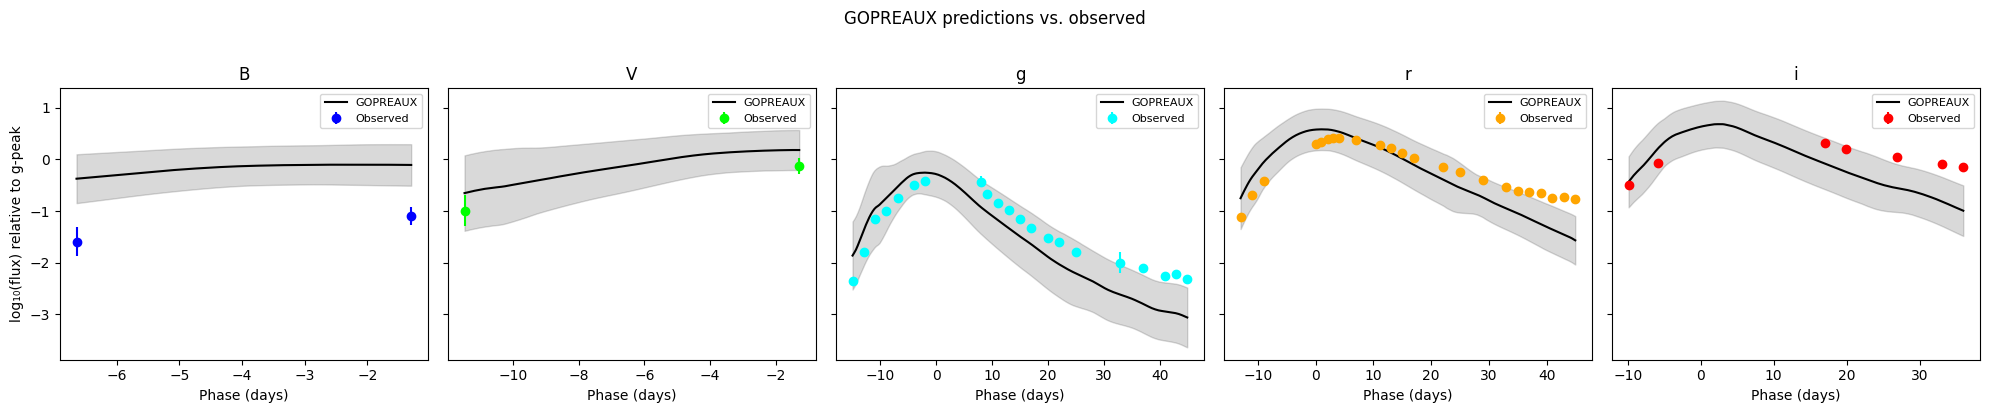

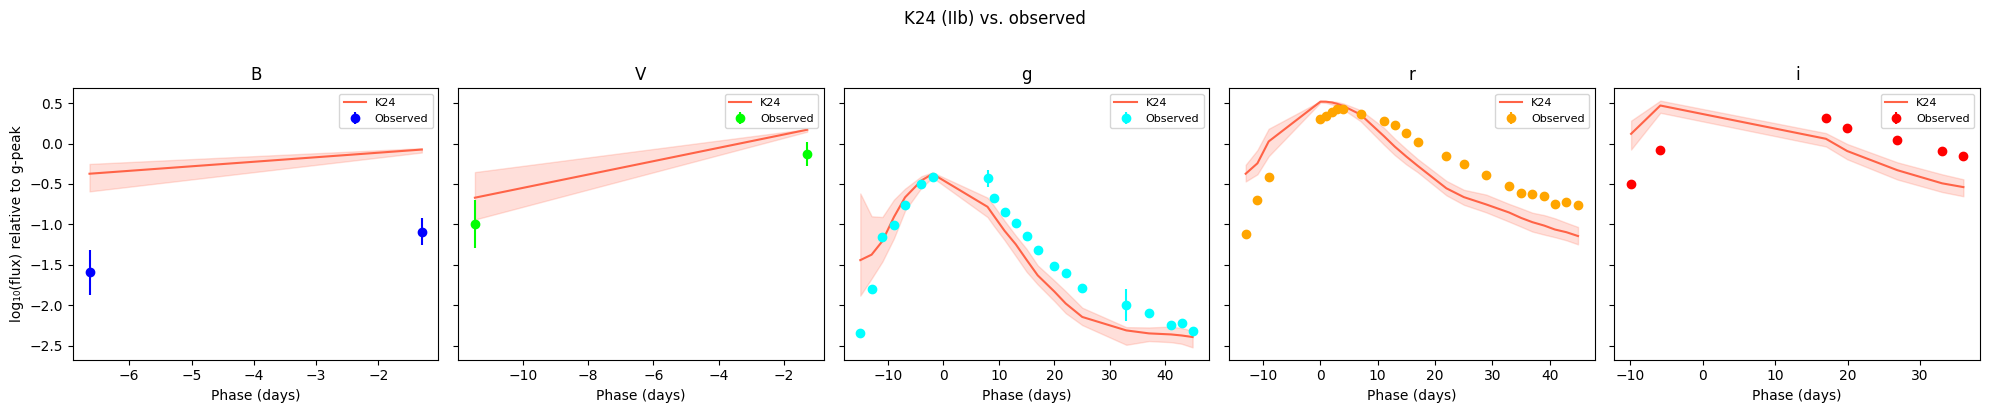

Evaluating SN2020sbw (peak_filt=g)...


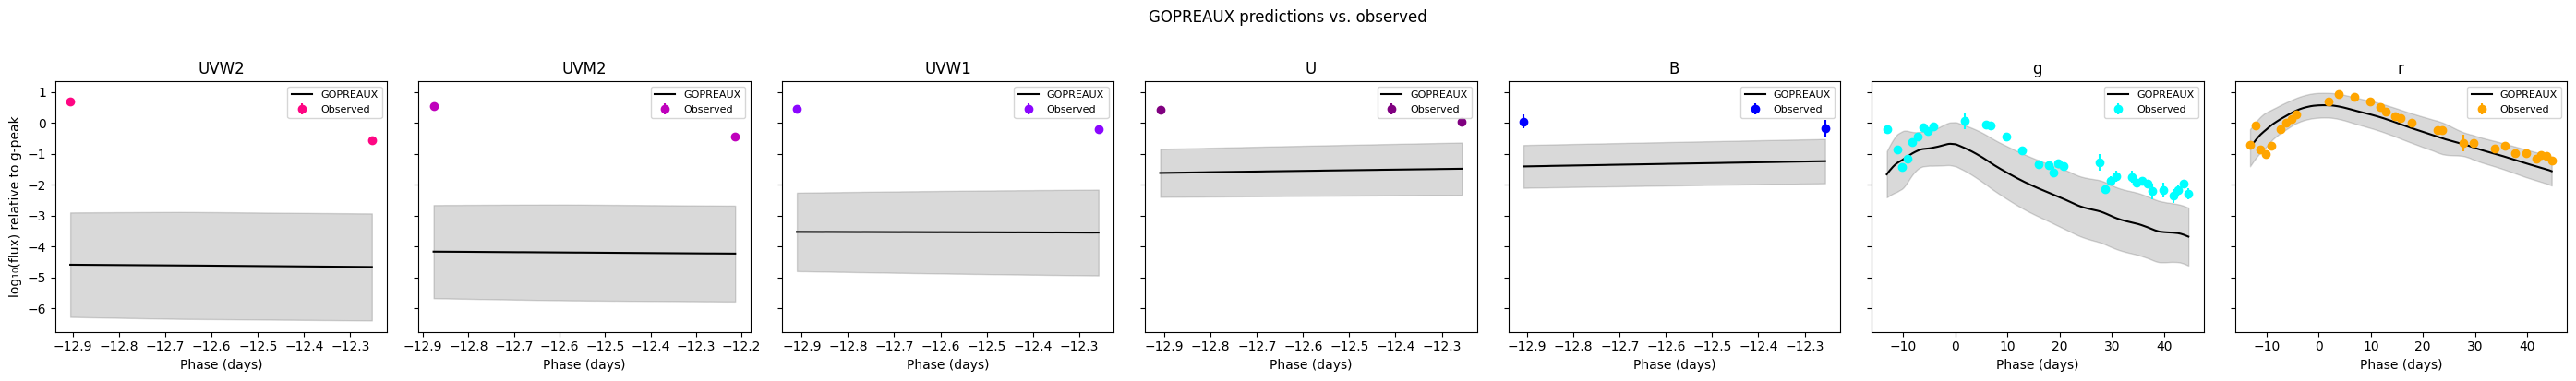

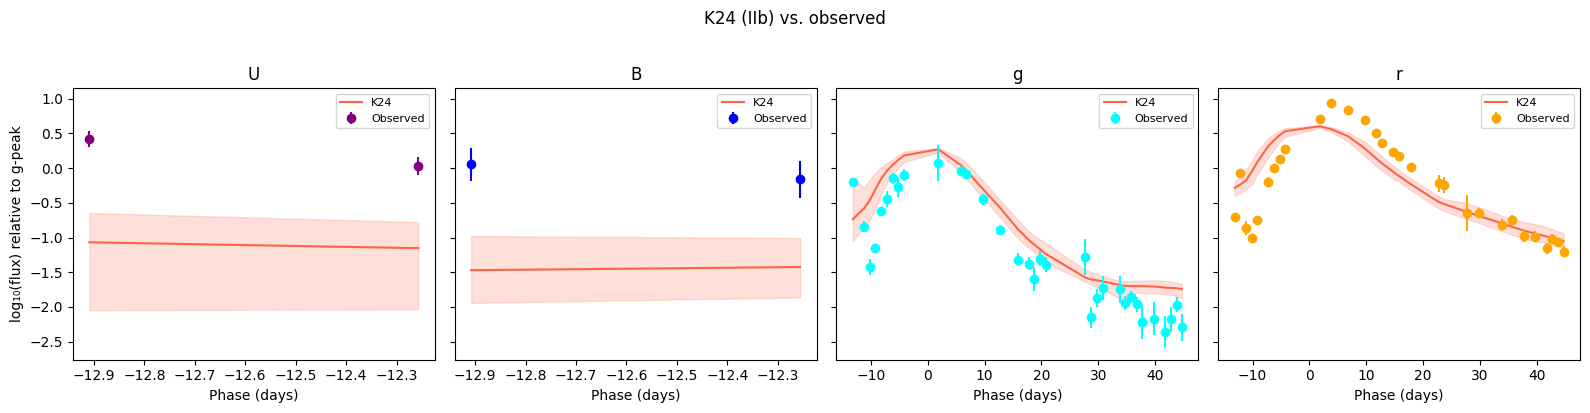

Evaluating SN2009mg (peak_filt=V)...


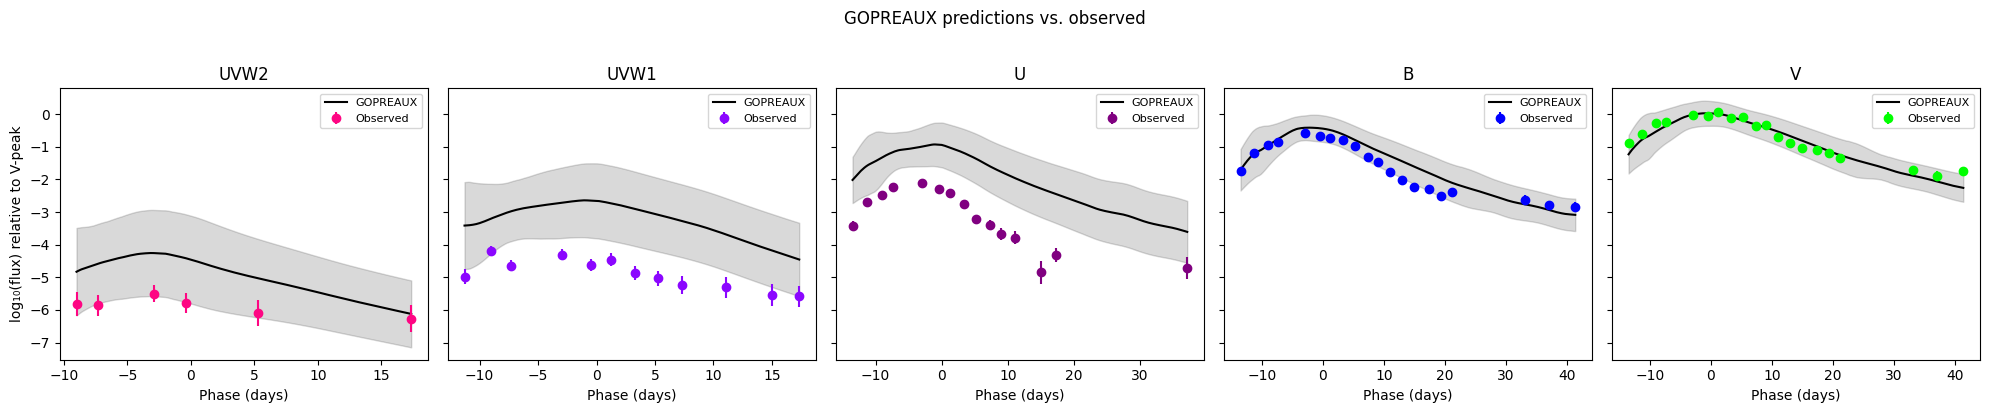

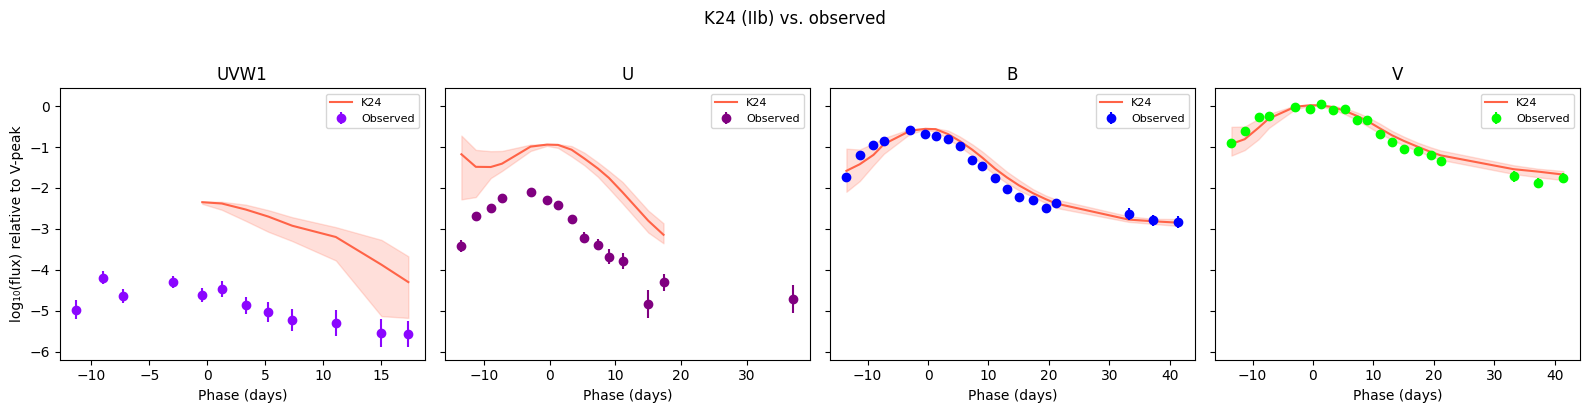

Evaluating SN2021uqw (peak_filt=r)...


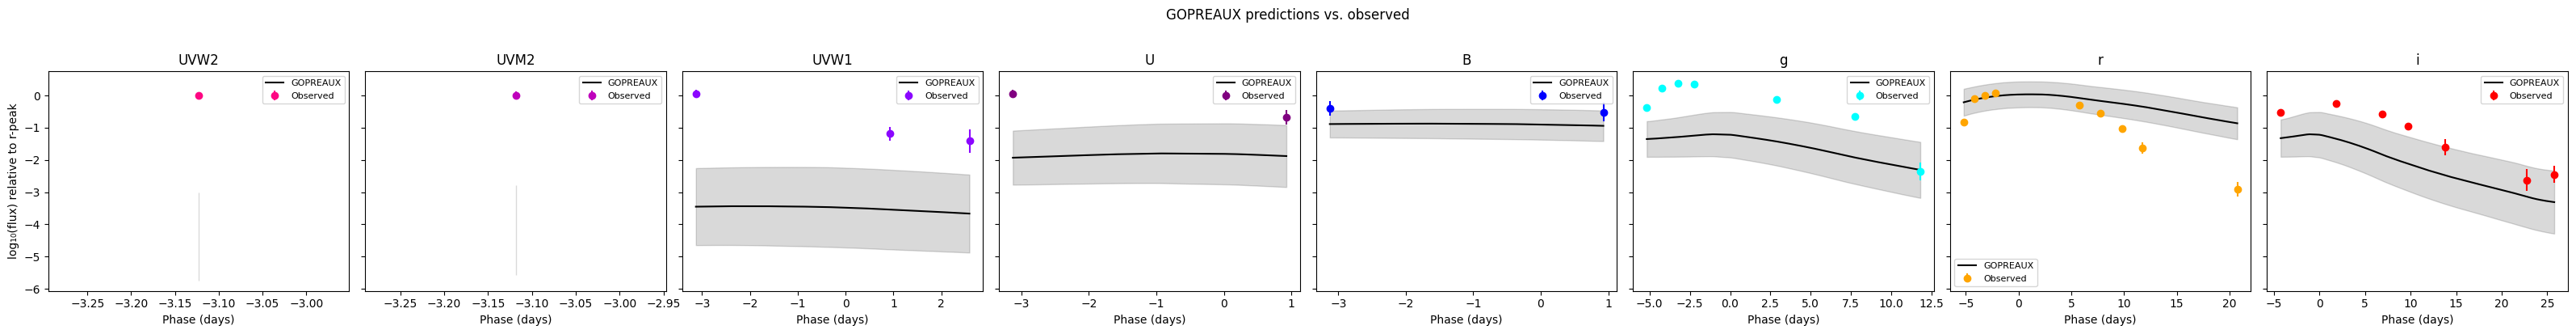

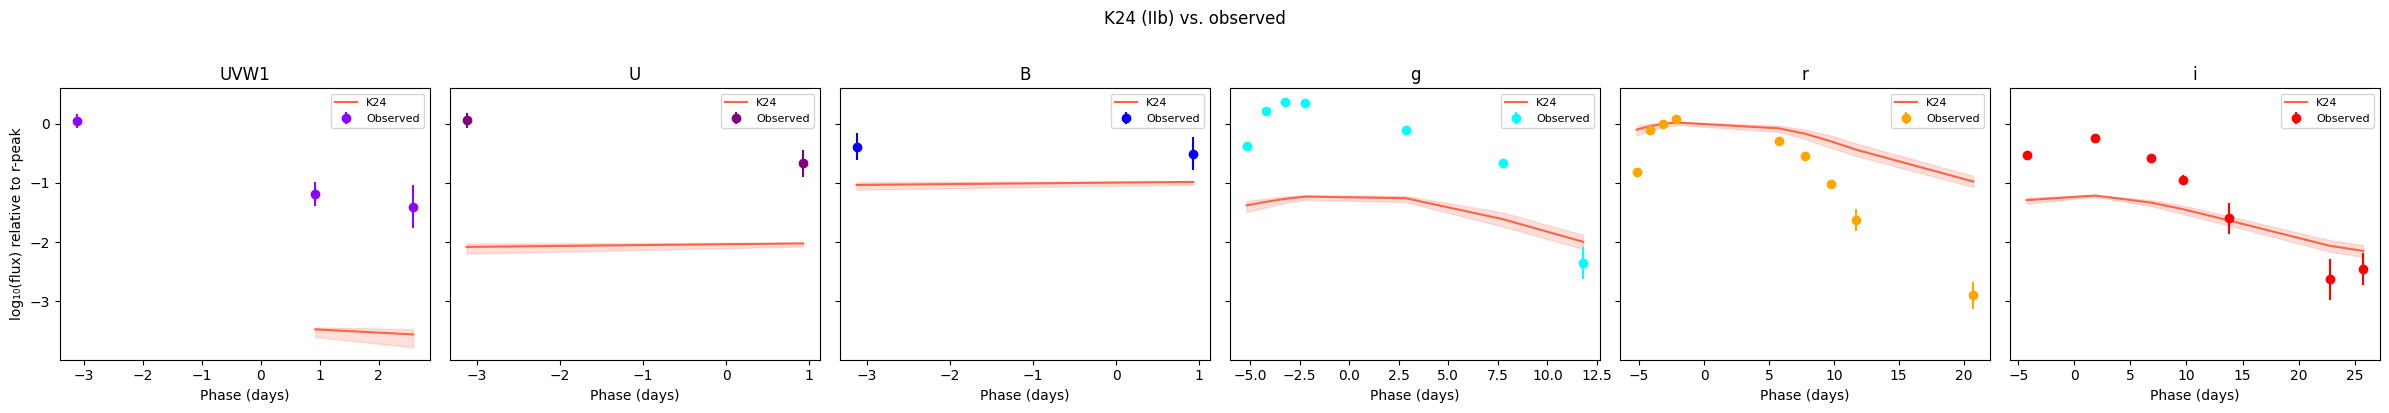

Evaluating SN2011hs (peak_filt=V)...


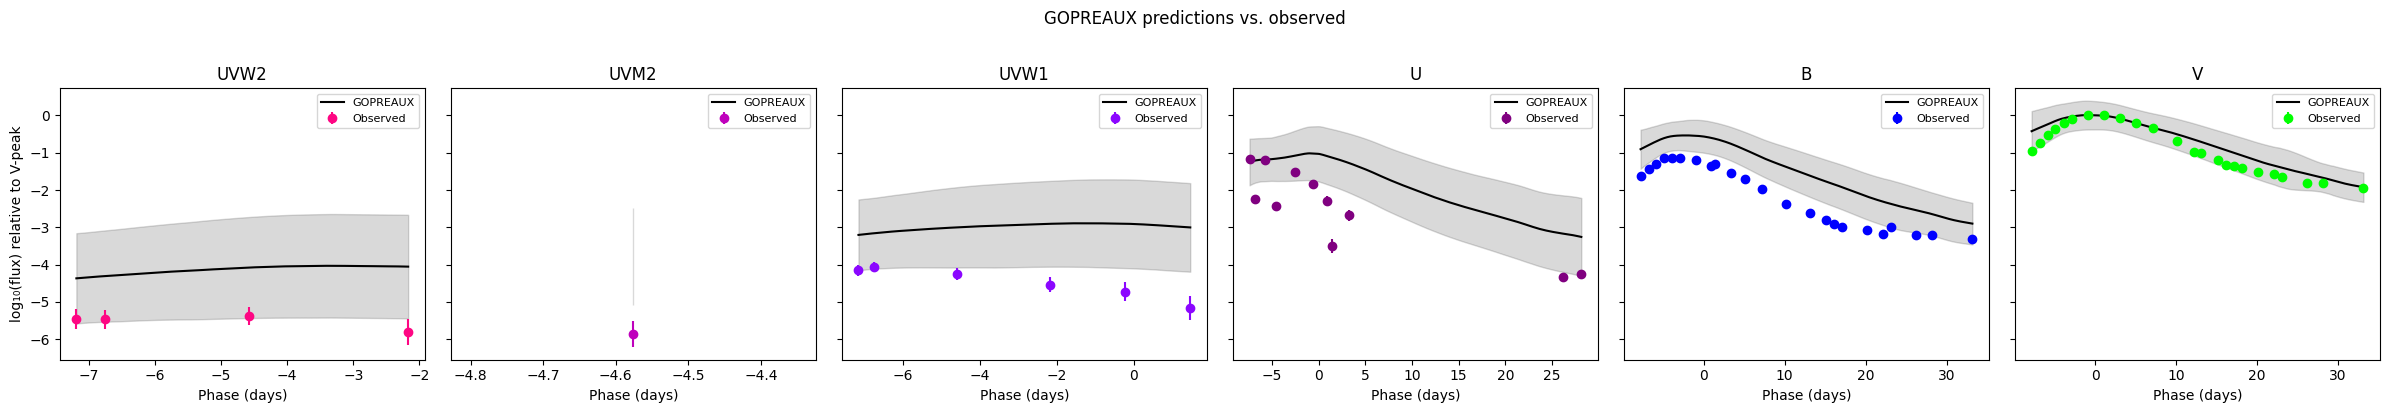

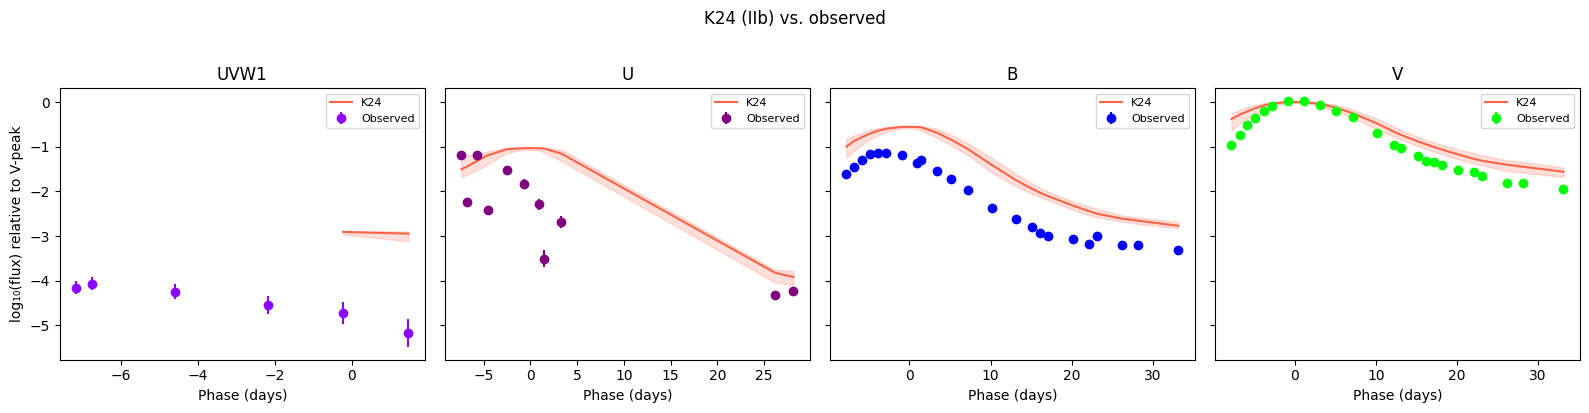

Evaluating SN2020rsc (peak_filt=r)...


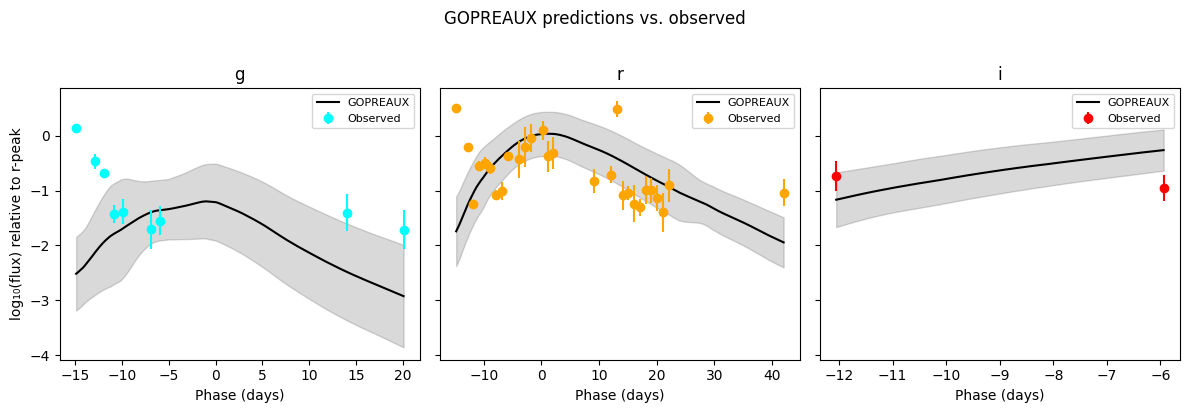

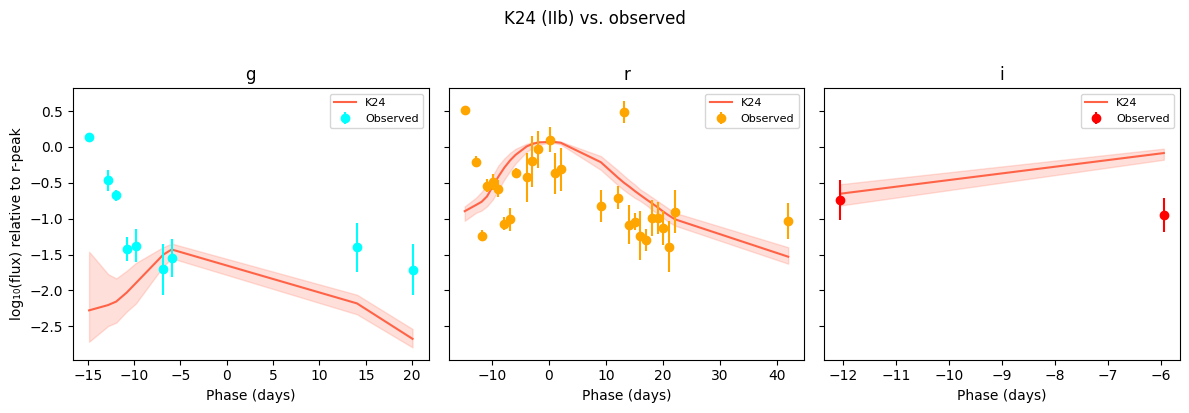

Evaluating SN2022hnt (peak_filt=o)...
  SN2022hnt: no usable detections in BAND_MAP filters
Evaluating SN2021ybc (peak_filt=g)...


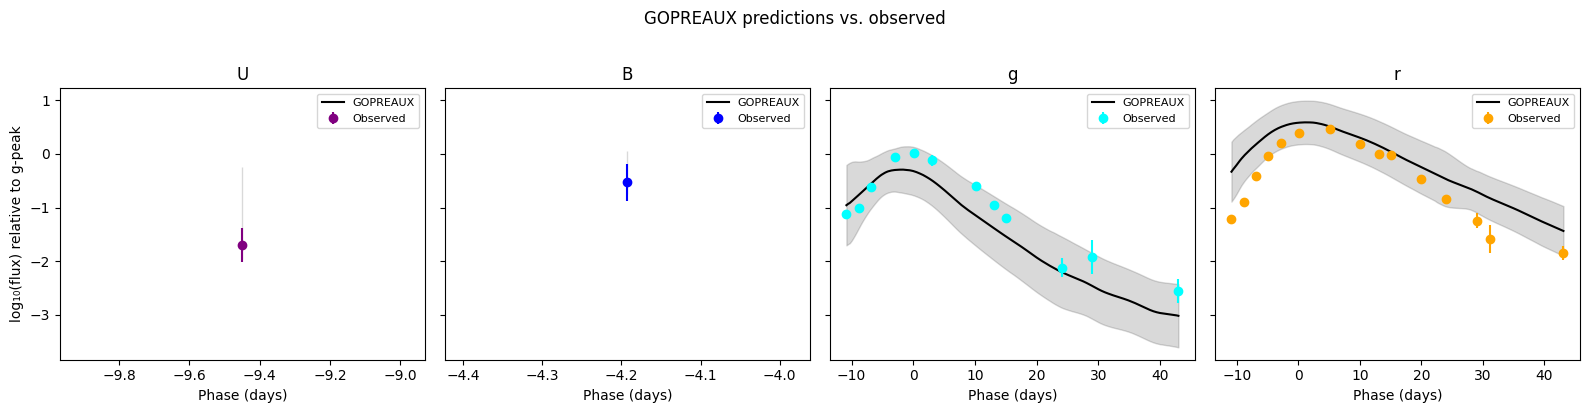

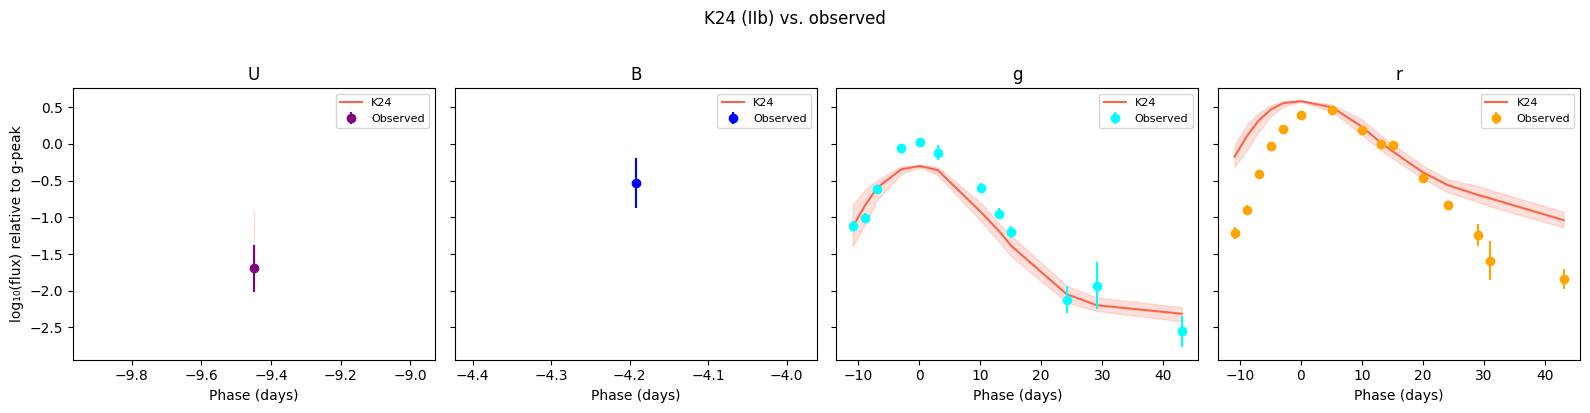

Evaluating SN2016gkg (peak_filt=V)...


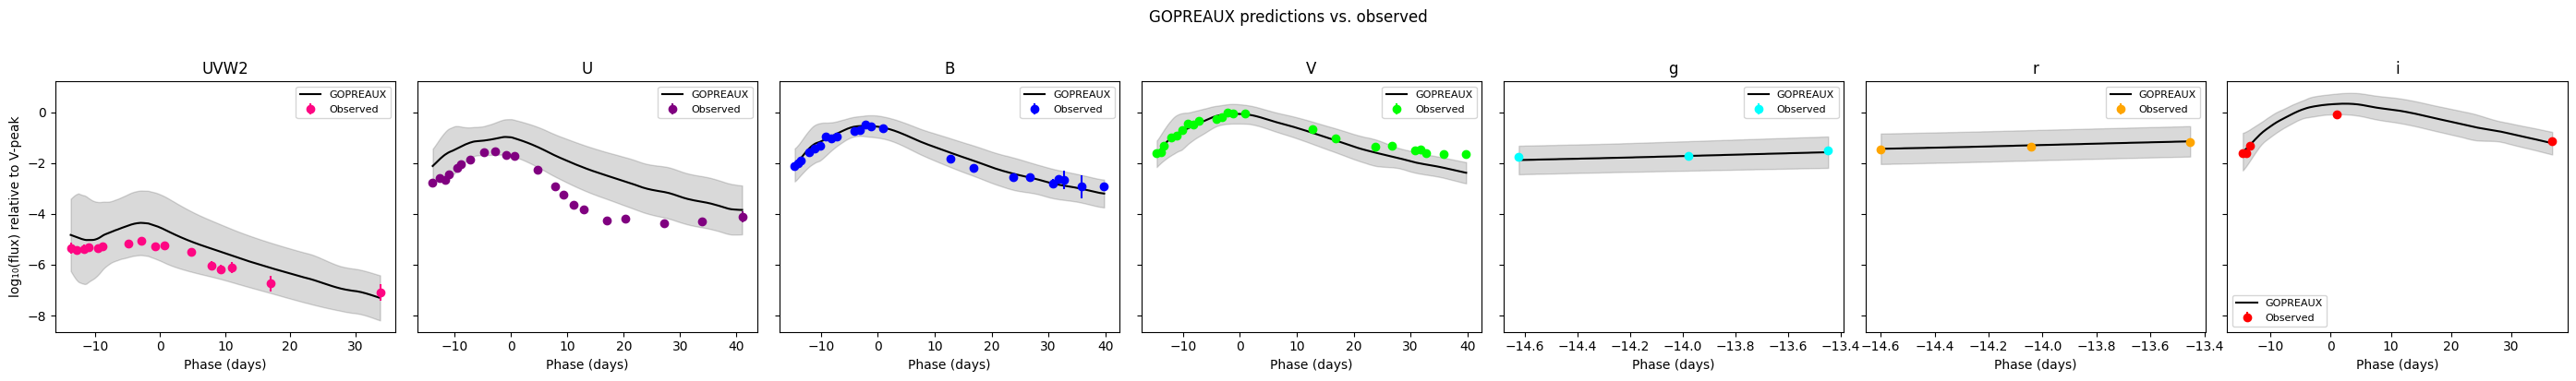

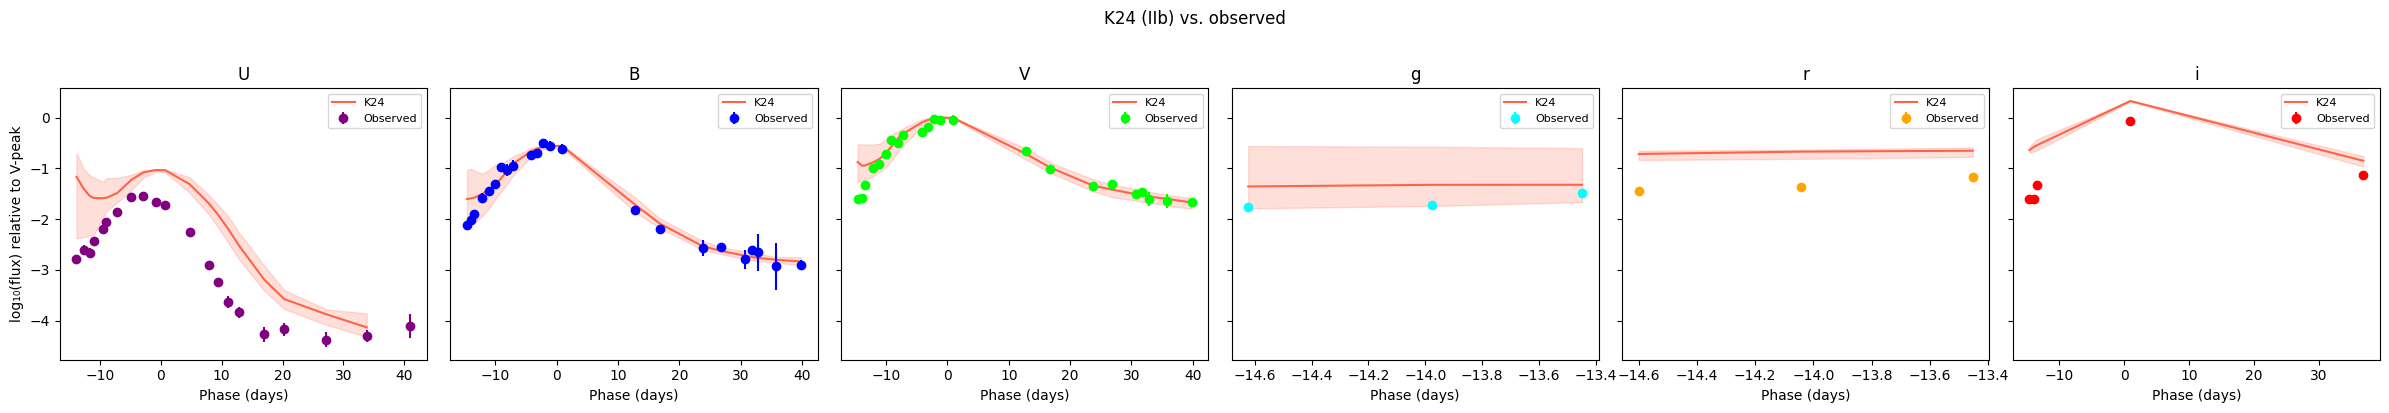

Evaluating SN2021sjt (peak_filt=c)...


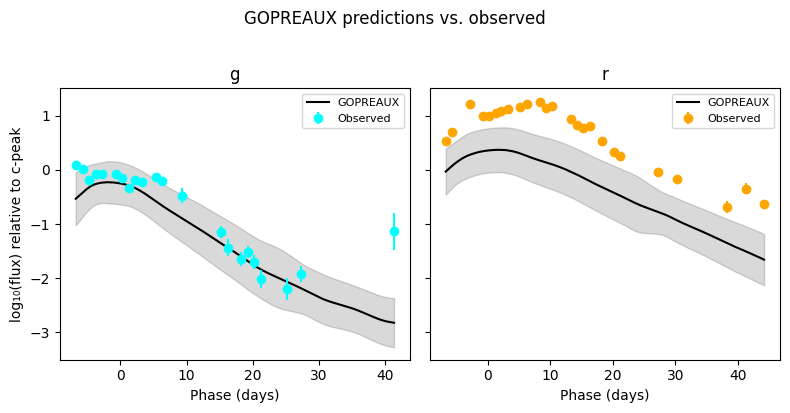

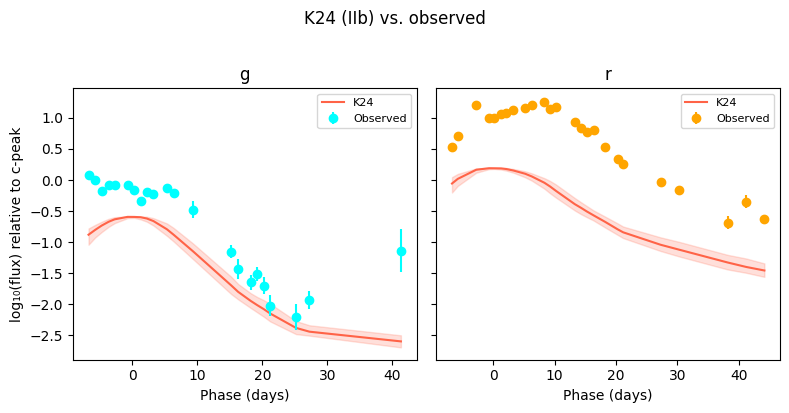

Evaluating SN2022eji (peak_filt=c)...


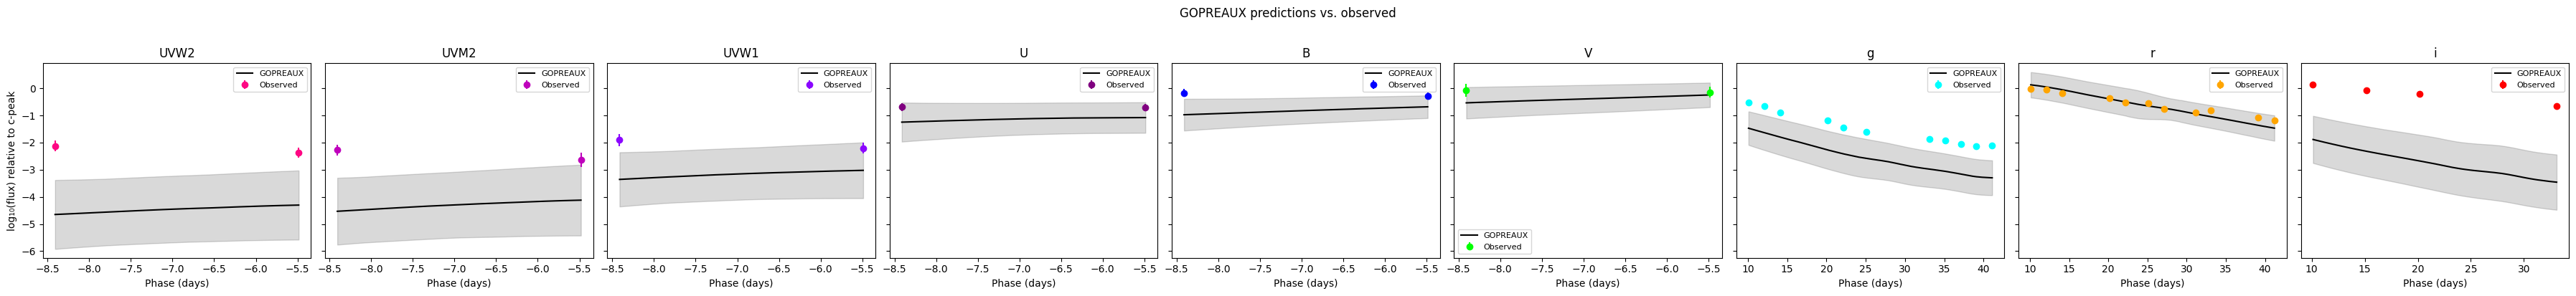

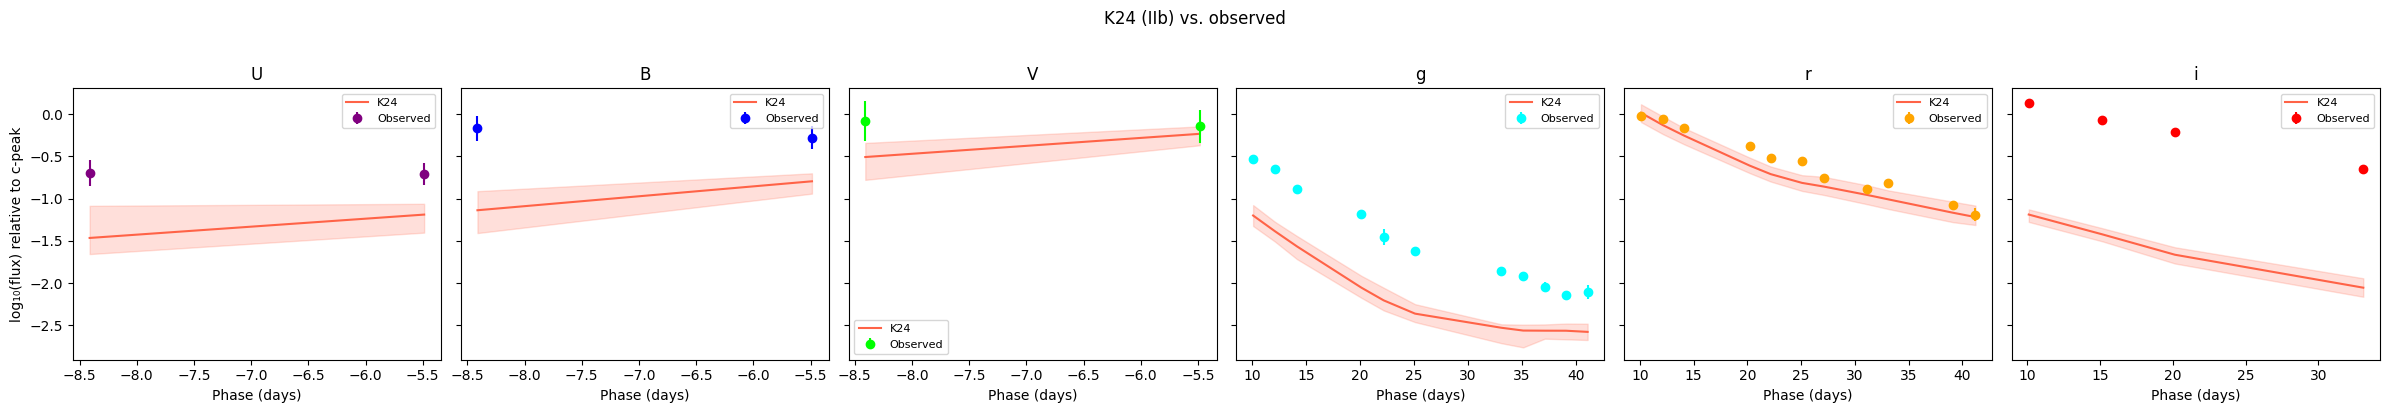

Evaluating SN2020acat (peak_filt=g)...


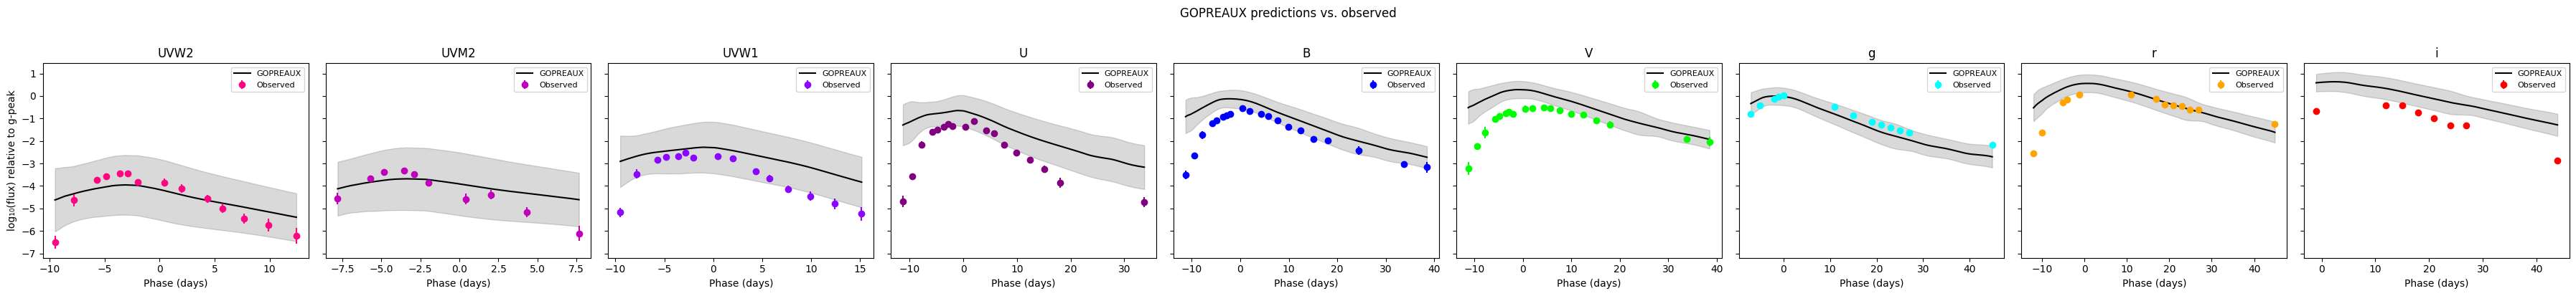

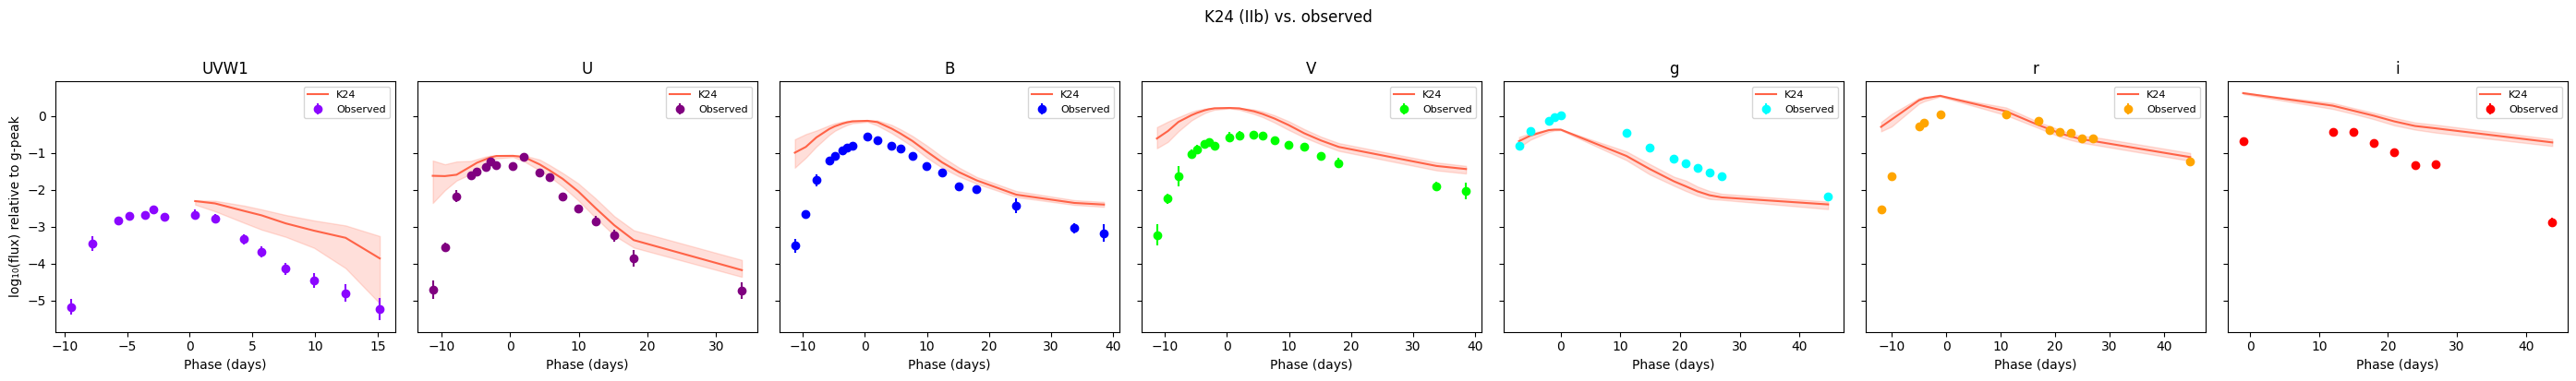

Evaluating SN2016bmd (peak_filt=V)...


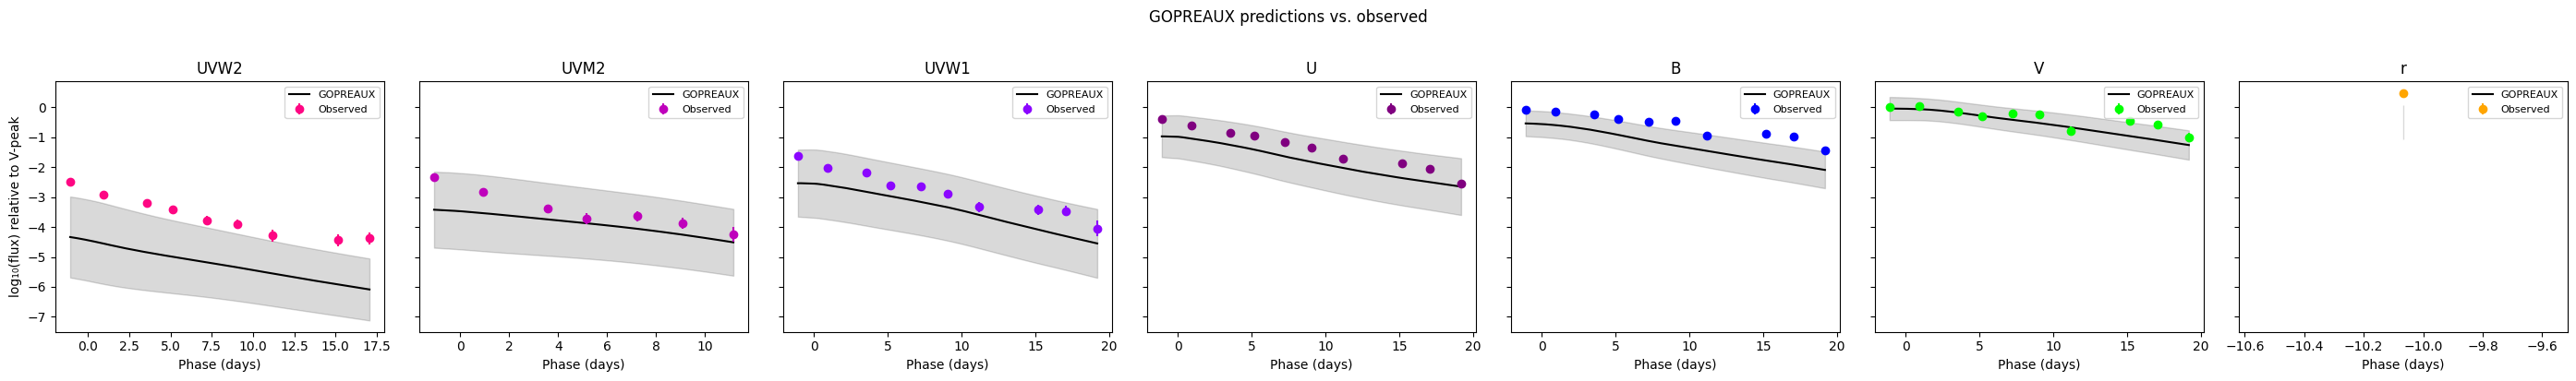

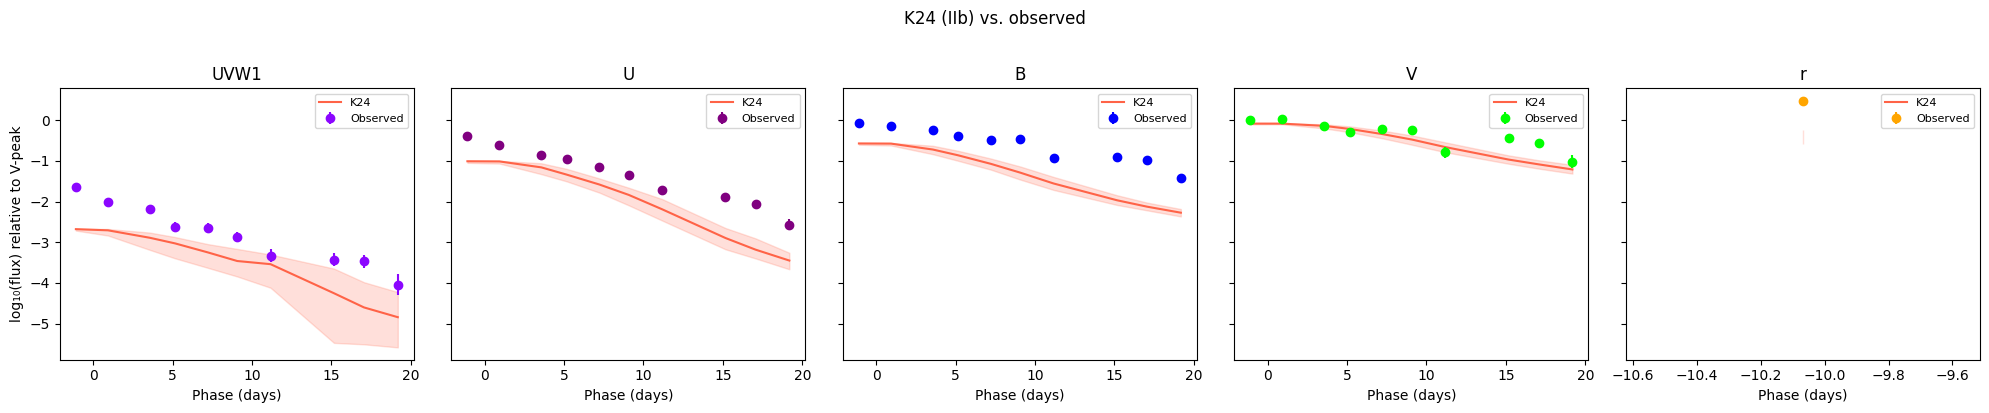

Evaluating SN2006T (peak_filt=g)...


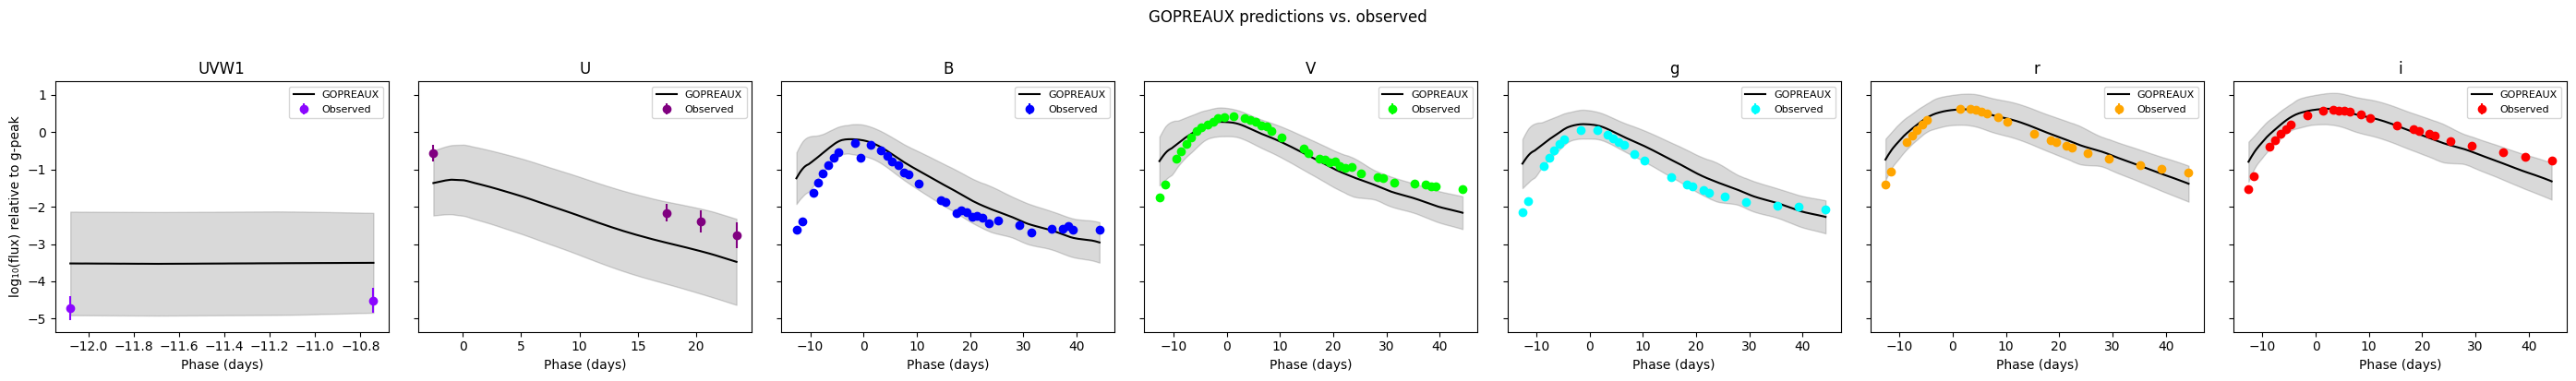

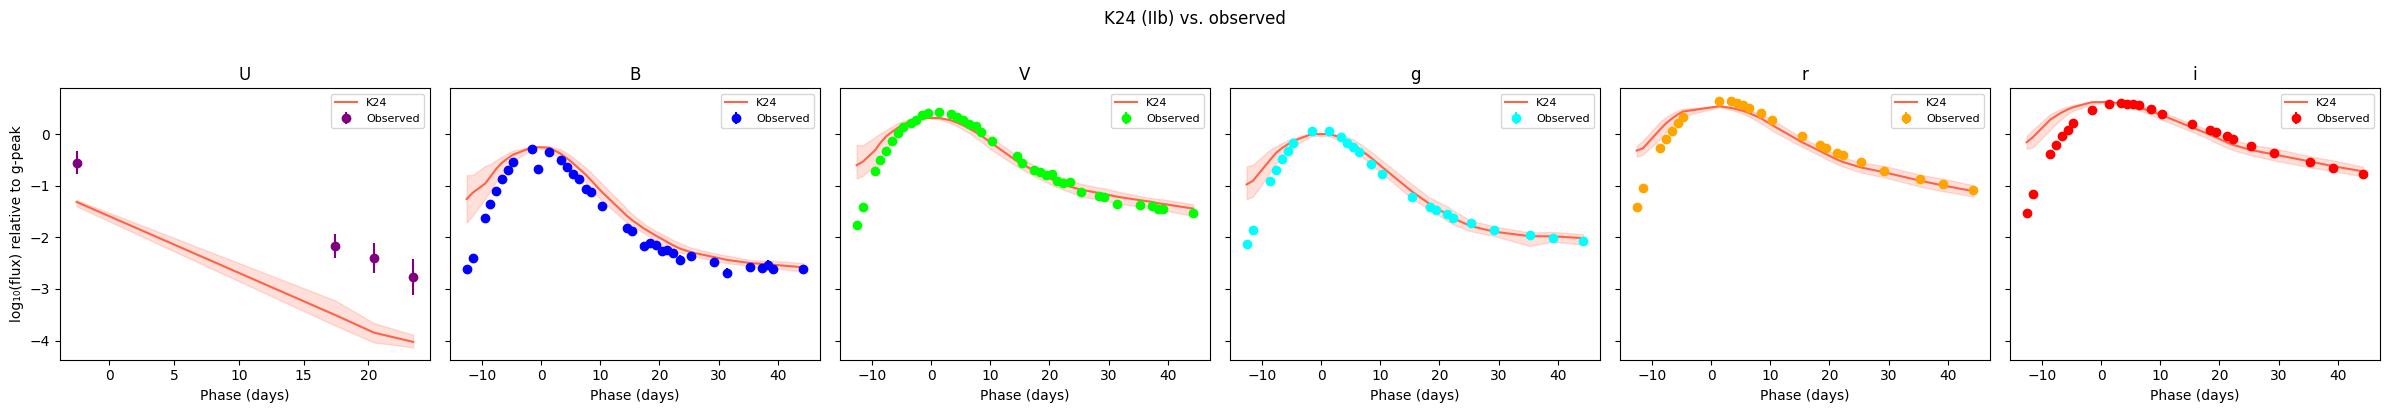

Evaluating SN2009mk (peak_filt=V)...


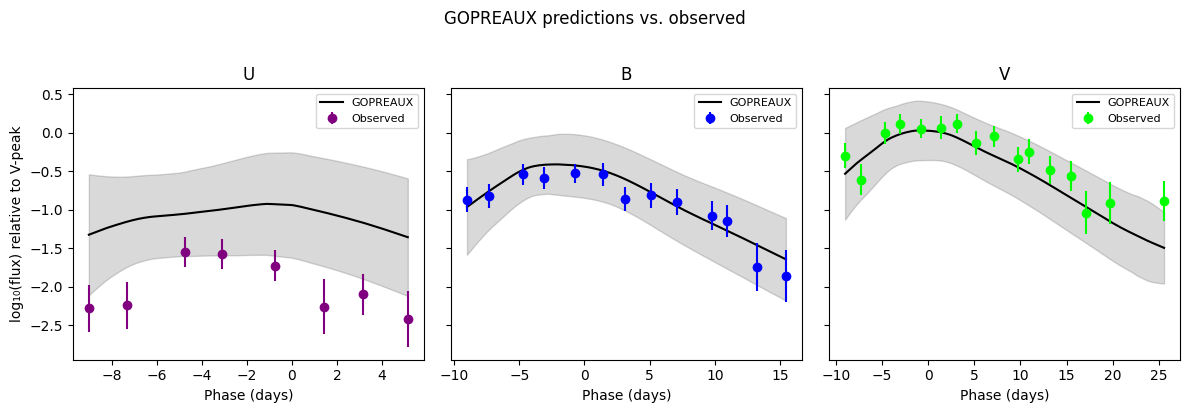

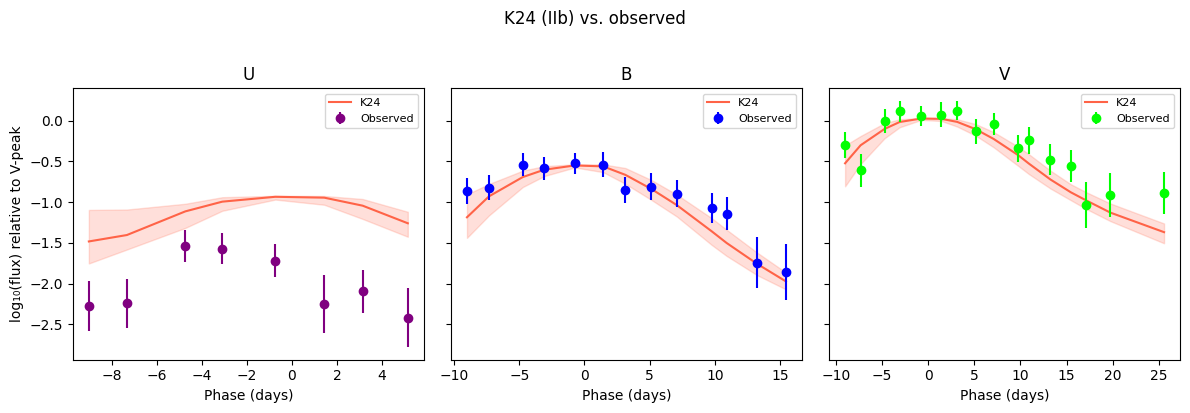

Evaluating SN2020xlt (peak_filt=g)...


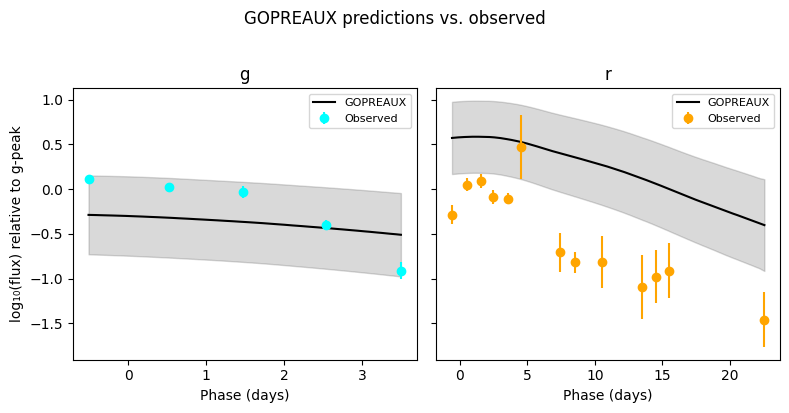

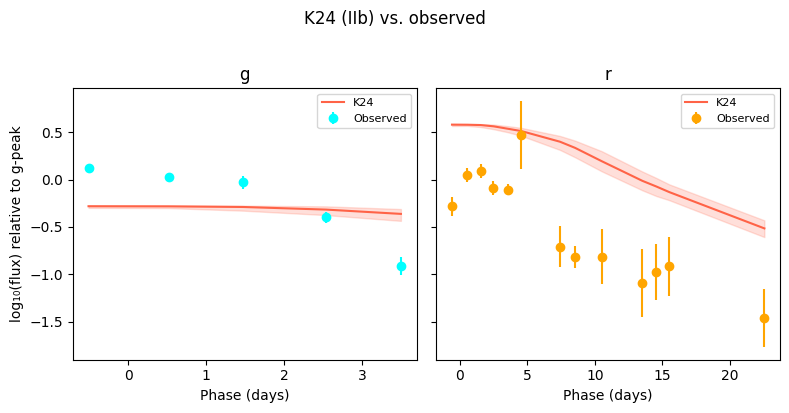

Evaluating SN2020ikq (peak_filt=g)...


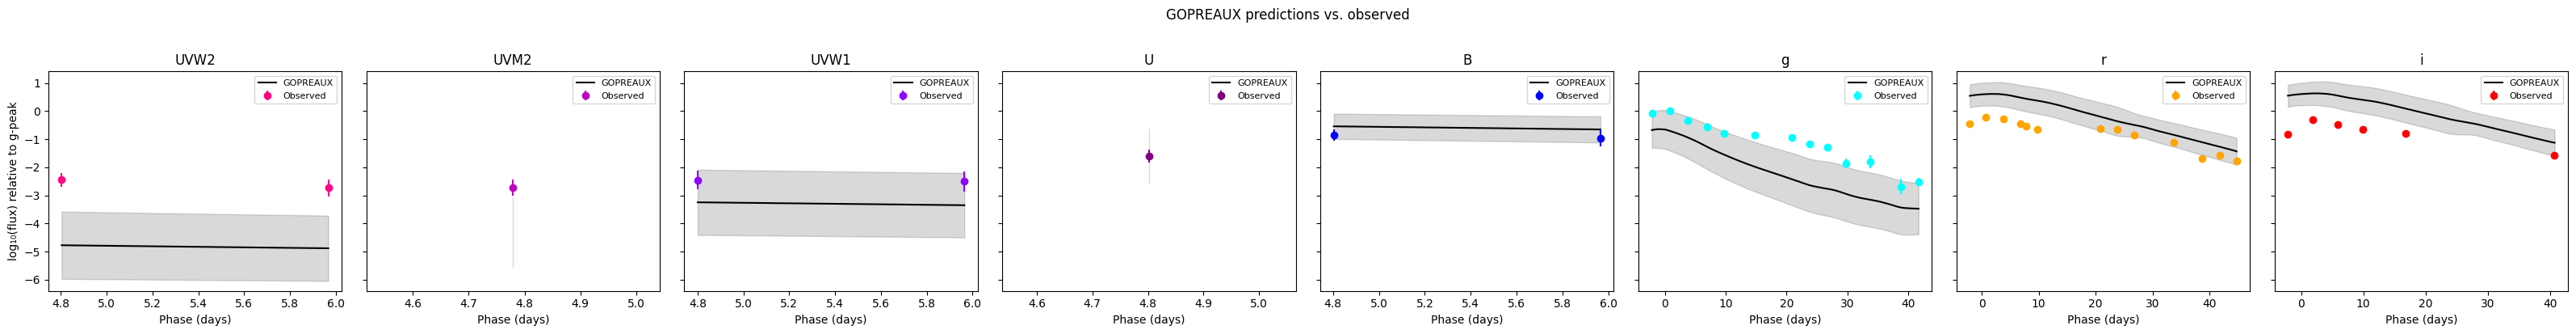

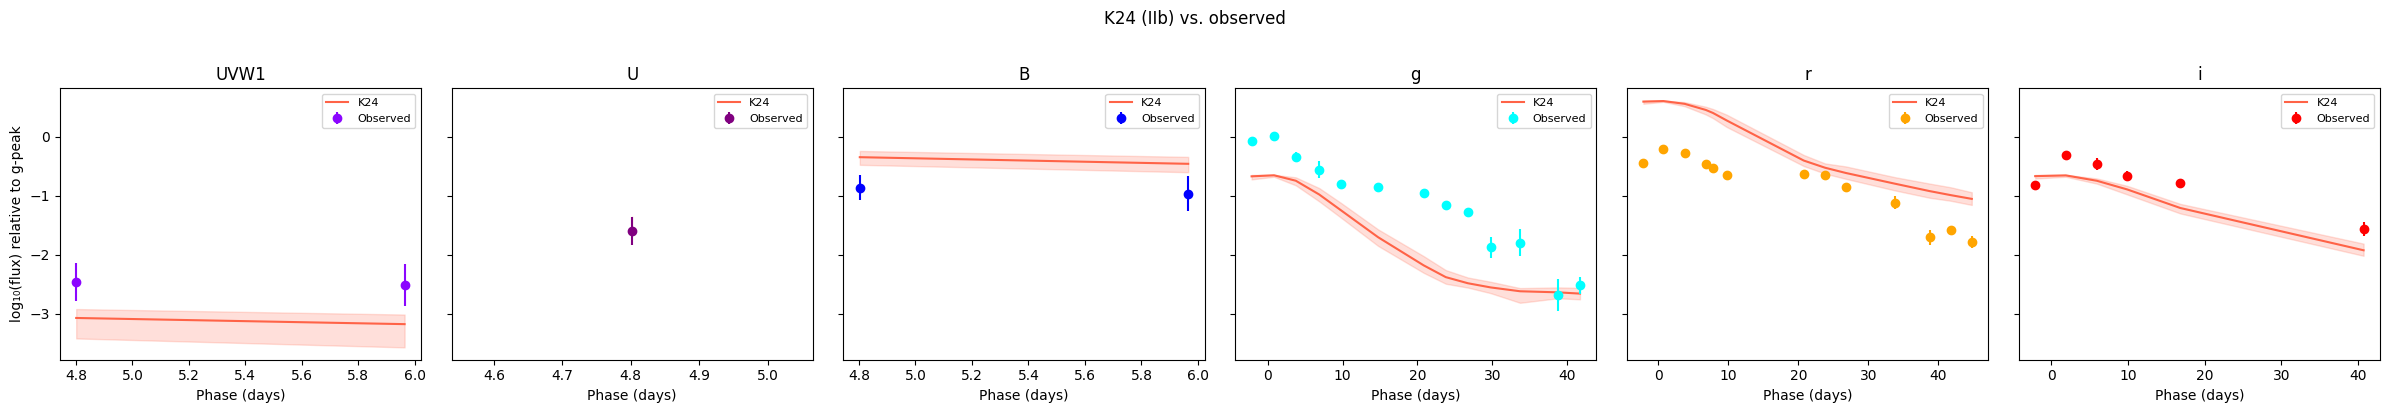

Evaluating SN2021pb (peak_filt=g)...


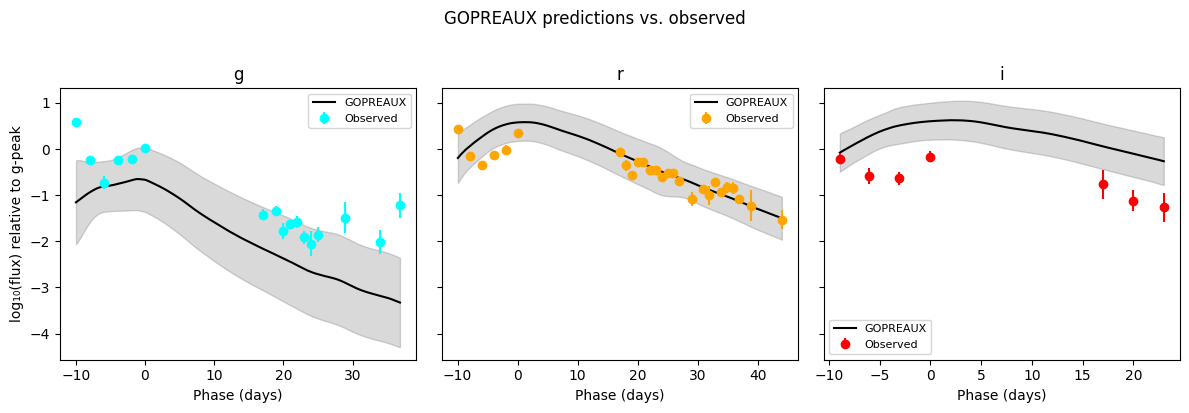

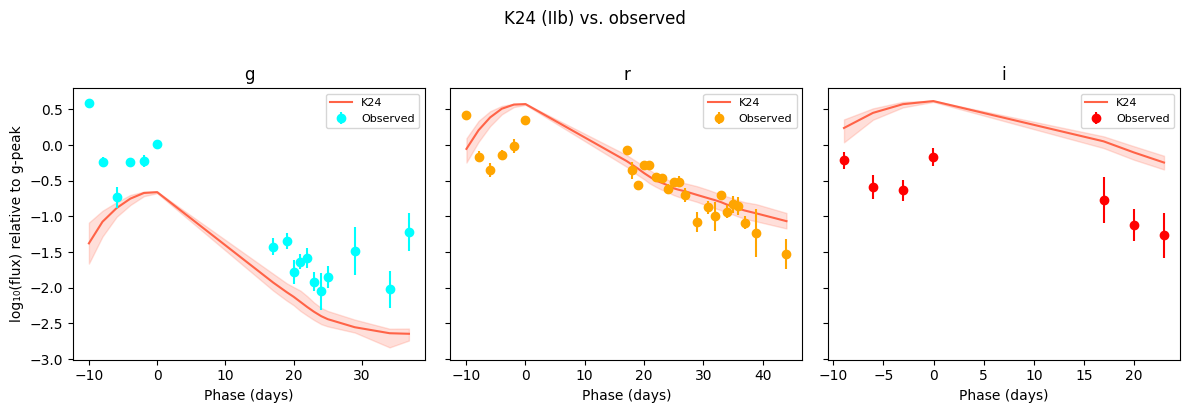

Evaluating SN2022qzr (peak_filt=g)...


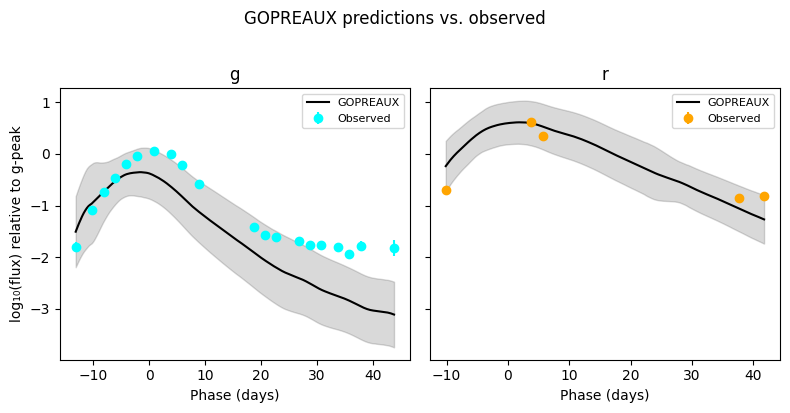

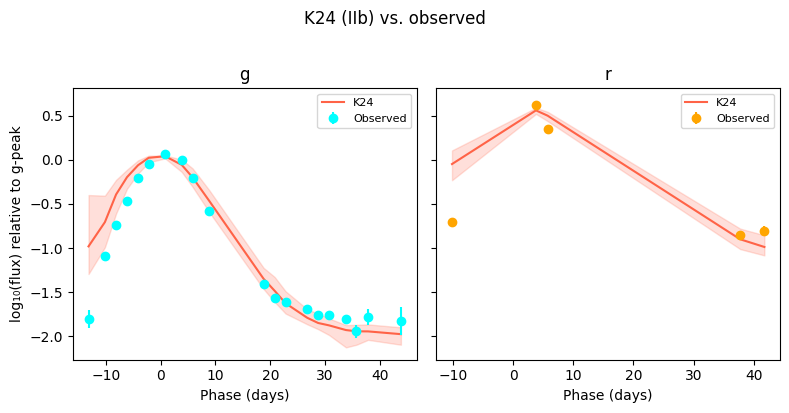

Evaluating SN2019hte (peak_filt=r)...


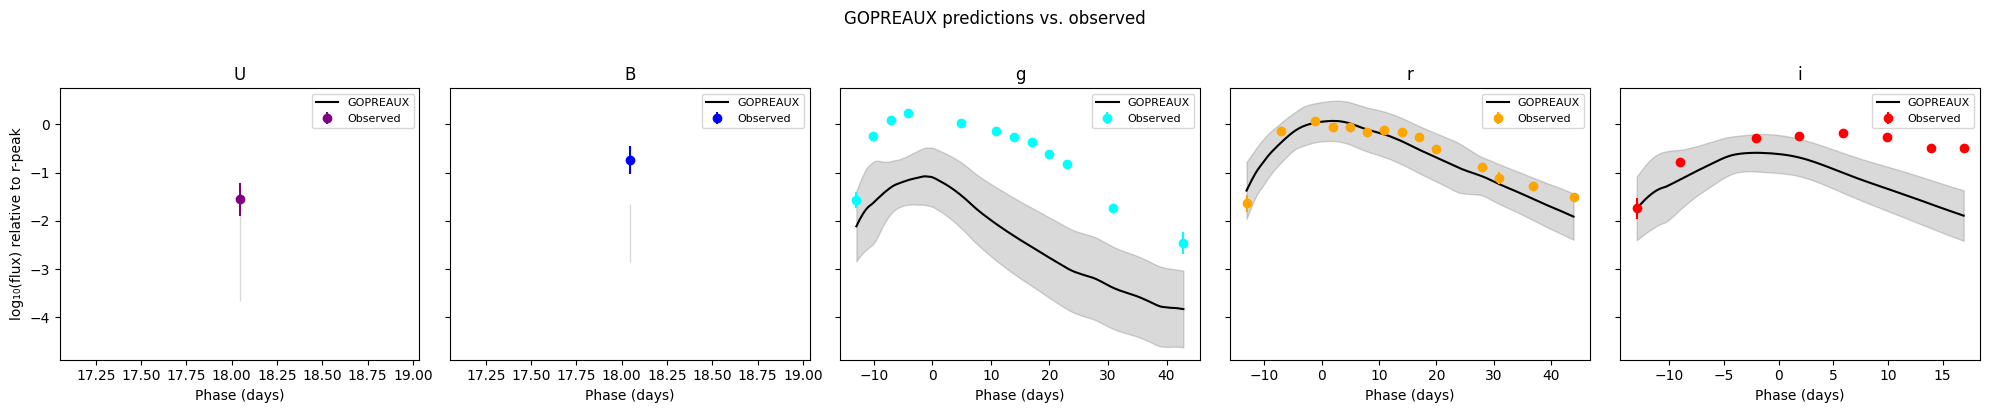

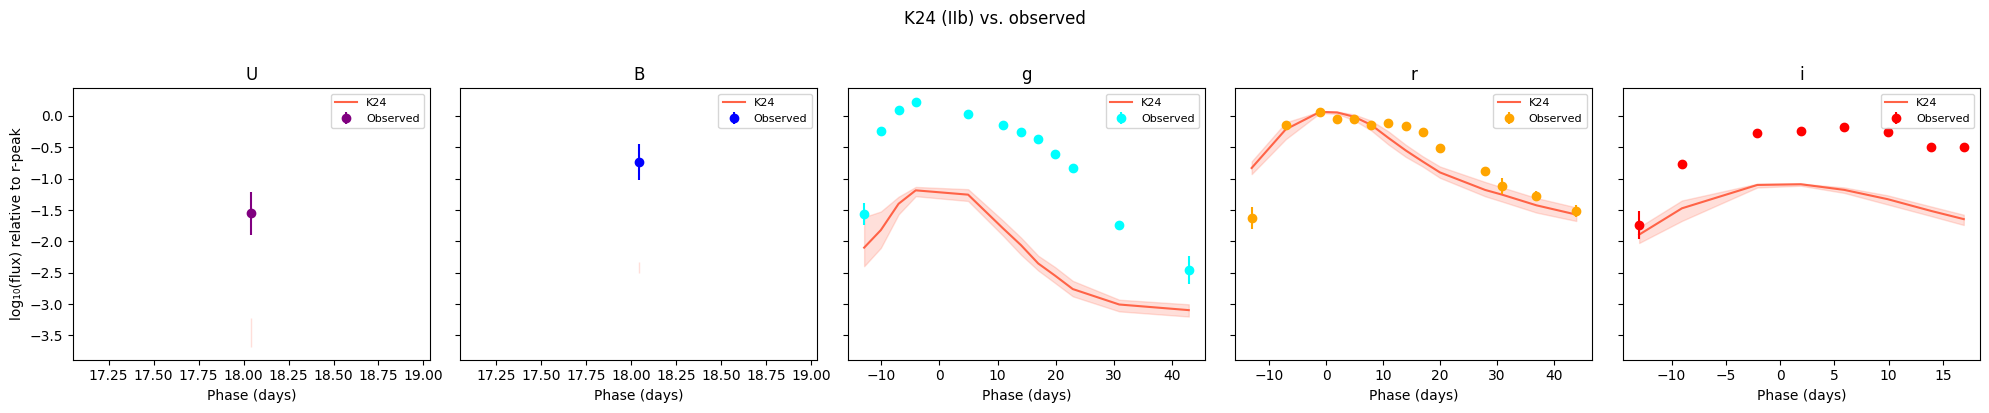

Evaluating SN2019rn (peak_filt=g)...


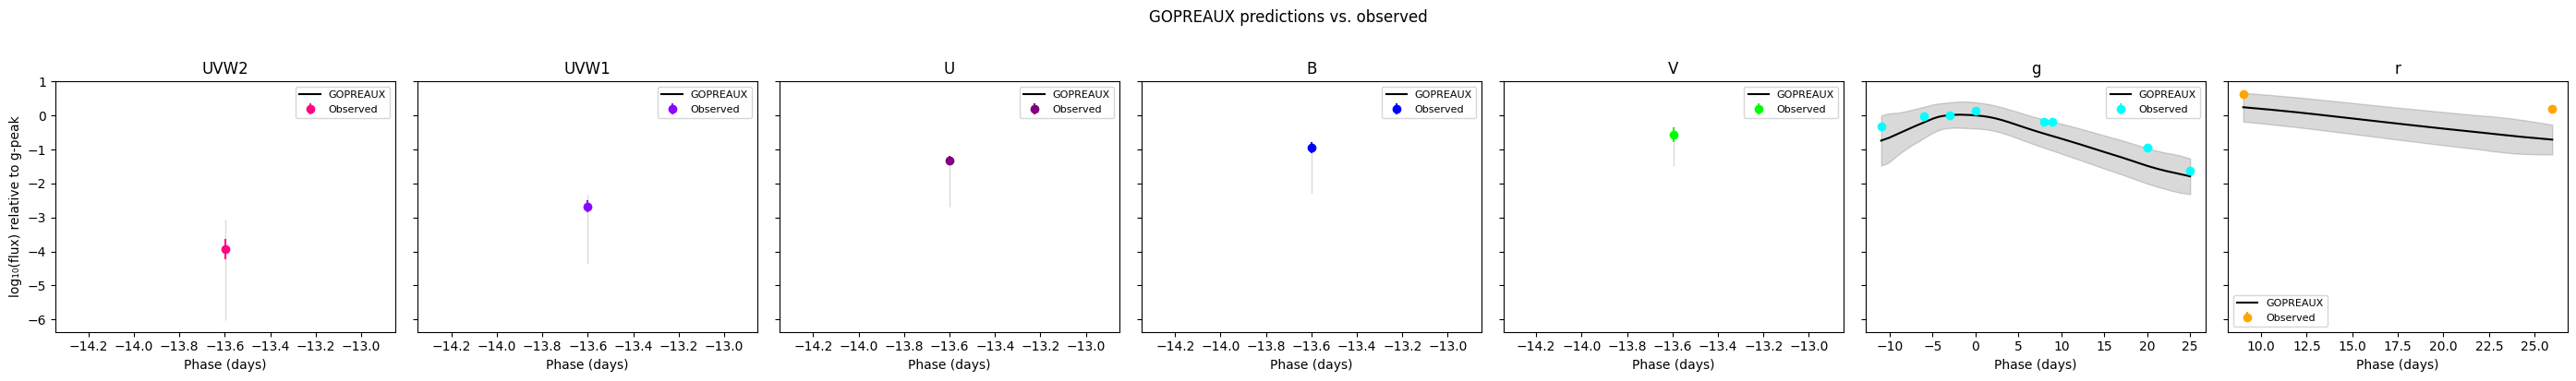

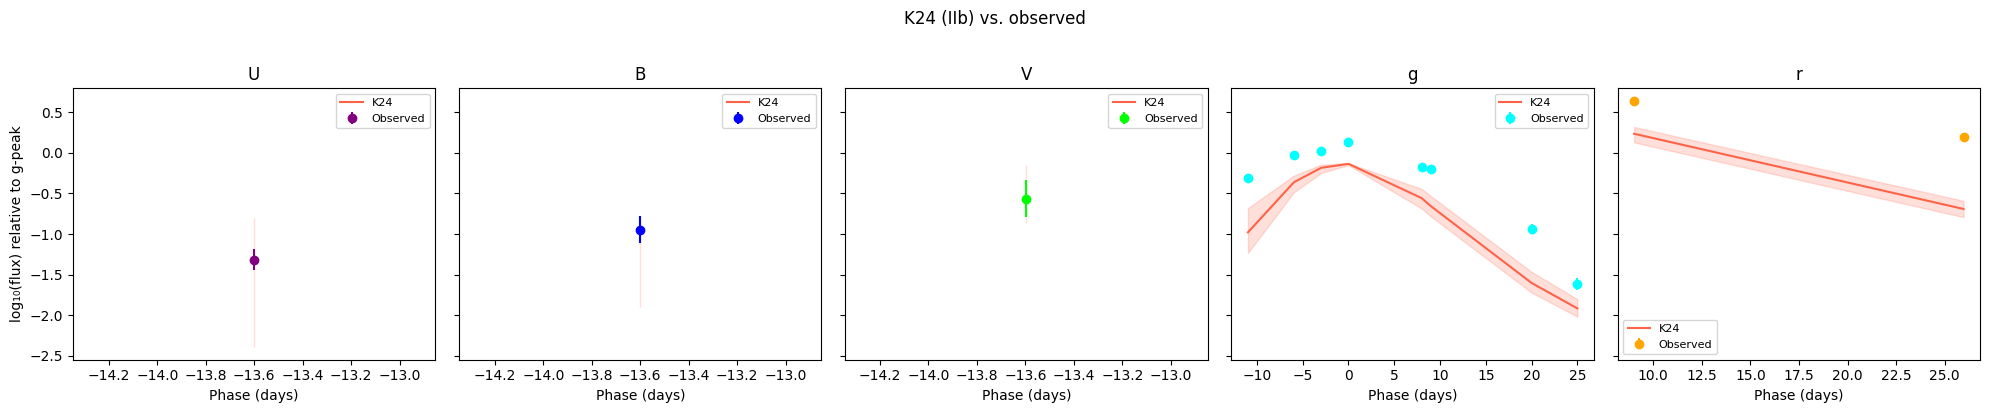

Evaluating SN2006bf (peak_filt=V)...


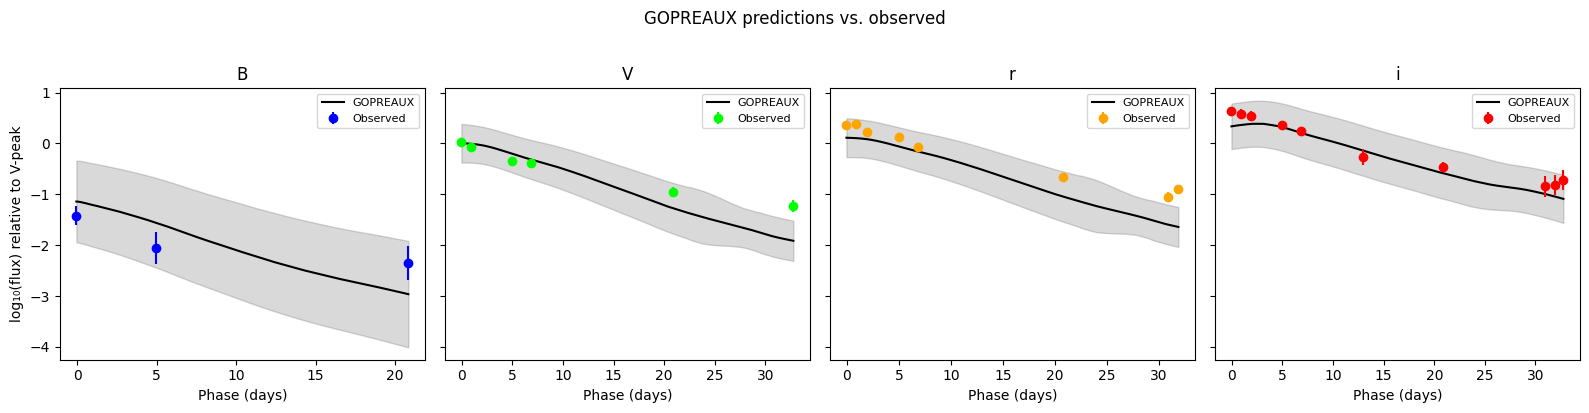

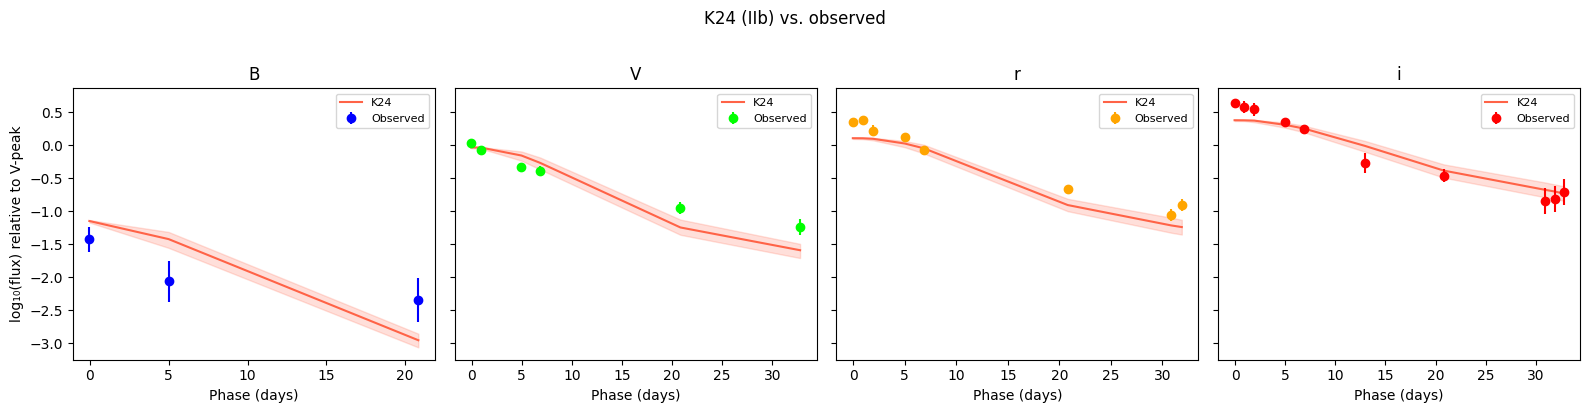

Evaluating SN2008cw (peak_filt=V)...


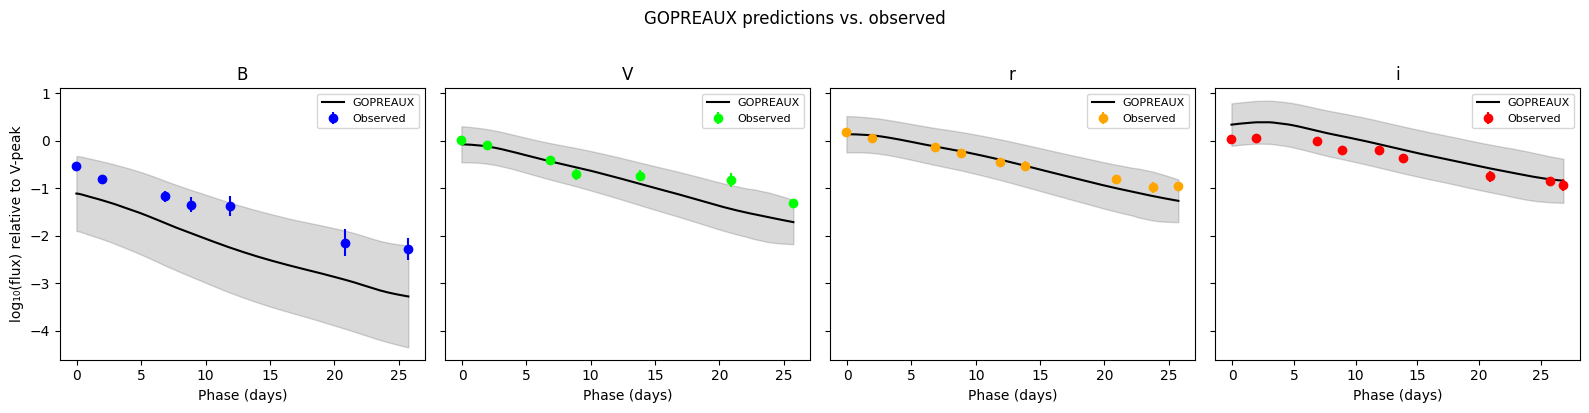

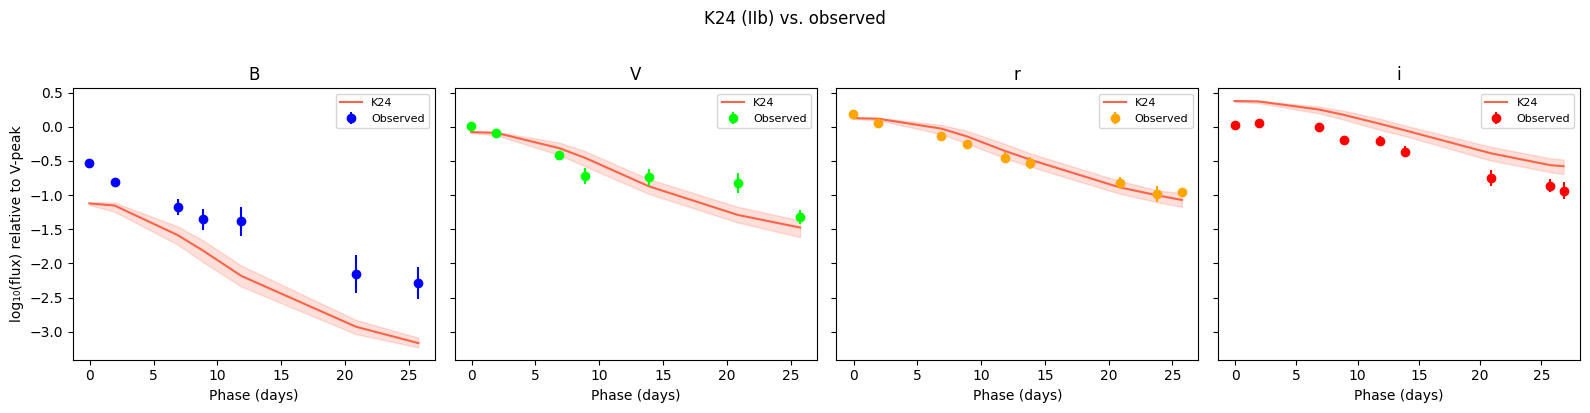

,SN,Filter,n_points,GOPREAUX_bias,GOPREAUX_mad,GOPREAUX_iqr,GOPREAUX_chi2,Khakpash_bias,Khakpash_mad,Khakpash_iqr,Khakpash_chi2
0,SN2022ngb,g,21,-0.341707,0.351019,0.695886,0.626068,-0.216705,0.134376,0.345531,0.253146
1,SN2022ngb,i,7,-0.435921,0.284150,0.495376,1.231817,-0.284342,0.098105,0.524751,0.765887
2,SN2022ngb,r,23,-0.116332,0.302587,0.589258,0.732285,-0.290303,0.102896,0.447779,0.496992
3,SN2020sbw,g,33,-1.136841,0.275343,0.640983,1.442830,0.266277,0.172078,0.306937,0.220177
4,SN2020sbw,r,30,-0.214422,0.140084,0.288125,0.506630,0.017147,0.290666,0.506267,0.541360
...,...,...,...,...,...,...,...,...,...,...,...
69,SN2006bf,r,8,-0.265864,0.125665,0.251651,0.897760,-0.204741,0.079933,0.141742,0.284546
70,SN2008cw,B,7,-0.603347,0.157023,0.251399,0.545946,-0.588144,0.186018,0.352863,0.433951
71,SN2008cw,V,7,-0.086710,0.091583,0.252732,0.343683,-0.085776,0.082883,0.189291,0.208889
72,SN2008cw,i,9,0.167924,0.082136,0.161098,0.204856,0.315204,0.041288,0.057224,0.445766


In [18]:
from caat import SN, SNModel, SNCollection

sn_subtype = "SNIIb"
snmodel = SNModel(
    surface=f"SESNe_{sn_subtype}_GP_model.fits"
)

with open(os.path.join(ROOT_DIR, "data", "comparison_models", "Khakpash24", "all_templates.pkl"), 'rb') as f:
    u = pkl._Unpickler(f)
    u.encoding = 'latin1'
    tmpl = u.load()

OBJECTS_TO_MODEL = [
    sn.name for sn in SNCollection(sntype="SESNe", snsubtype=sn_subtype).sne
]

all_results = []
for sn_name in OBJECTS_TO_MODEL:
    sn_obj = SN(name=sn_name)
    peak_filter = sn_obj.info.get("peak_filt", "")
    cube_path = os.path.join(CUBE_ROOT, sn_subtype, sn_name, f"{sn_name}_datacube_mangled.csv")

    if not peak_filter or not os.path.exists(cube_path):
        continue

    print(f"Evaluating {sn_name} (peak_filt={peak_filter})...")
    result = evaluate_sn(sn_name, sn_subtype, snmodel, tmpl, peak_filter, plot=True)
    if not result.empty:
        all_results.append(result)

results = pd.concat(all_results, ignore_index=True)
results


Median MAD and reduced chi^2 per filter (lower is better):

        GOPREAUX_mad  Khakpash_mad  GOPREAUX_chi2  Khakpash_chi2
Filter                                                          
B           0.131476      0.134535       0.599109       0.421223
U           0.223996      0.286261       1.938627       1.396569
UVM2        0.271874           NaN       0.224333            NaN
UVW1        0.359112      0.170300       1.252408       1.825478
UVW2        0.140233           NaN       0.463208            NaN
V           0.112226      0.089717       0.352841       0.208889
g           0.197751      0.139078       1.112533       0.756486
i           0.131369      0.133495       1.349957       0.813575
r           0.162980      0.157547       0.815023       0.519176


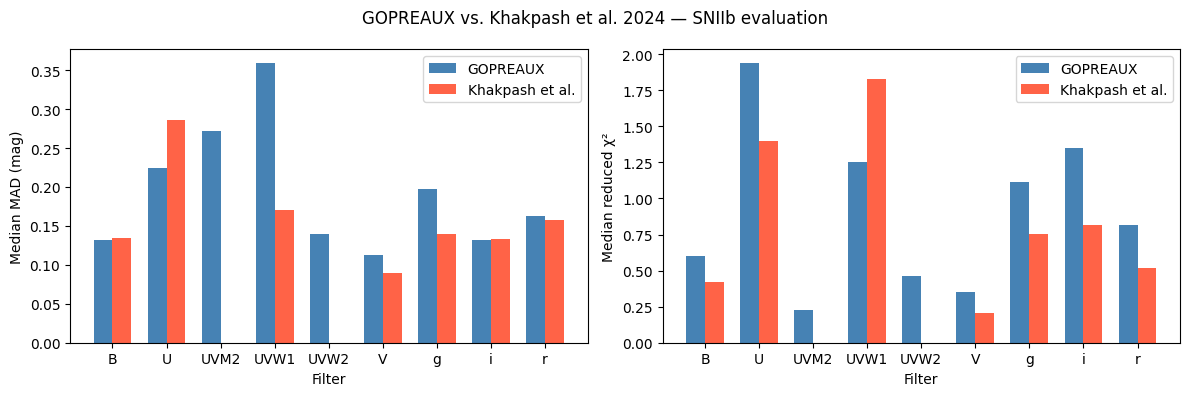

In [19]:
import matplotlib.pyplot as plt

# Summary: median MAD per model across all hold-out SNe and filters
summary = results.groupby("Filter")[["GOPREAUX_mad", "Khakpash_mad", "GOPREAUX_chi2", "Khakpash_chi2"]].median()
print("Median MAD and reduced chi^2 per filter (lower is better):\n")
print(summary.to_string())

# Bar chart: MAD by filter
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
x = range(len(summary))
width = 0.35

for ax, metric, label in zip(
    axes,
    [("GOPREAUX_mad", "Khakpash_mad"), ("GOPREAUX_chi2", "Khakpash_chi2")],
    ["Median MAD (mag)", "Median reduced χ²"],
):
    gp_vals = summary[metric[0]].values
    k24_vals = summary[metric[1]].values
    ax.bar([i - width/2 for i in x], gp_vals, width, label="GOPREAUX", color="steelblue")
    ax.bar([i + width/2 for i in x], k24_vals, width, label="Khakpash et al.", color="tomato")
    ax.set_xticks(list(x))
    ax.set_xticklabels(summary.index)
    ax.set_ylabel(label)
    ax.set_xlabel("Filter")
    ax.legend()

fig.suptitle(f"GOPREAUX vs. Khakpash et al. 2024 — {sn_subtype} evaluation")
plt.tight_layout()
plt.show()